# IC3392 updated-rerun QC: pyqz, NebulaBayes, and JY22

**Date:** 2026-08-24  
**Primary internal comparator:** O3N2-C20  
**Secondary calibration checks:** D16, PG16, and O3N2-M13

This notebook audits the newly downloaded IC3392 rerun after the NebulaBayes estimator and JY22 ratio/depletion fixes. It checks the abundance maps and every new method-specific auxiliary product, using one value per spatial `BIN_ID` rather than pixel-weighting repeated bin values.

The questions are deliberately separated:

1. Did the fresh FITS product actually ingest the updated method contracts without a schema, broadcast, or storage problem?
2. Are the metallicity zero points, dynamic ranges, and spatial responses sensible relative to O3N2-C20?
3. Which outputs are numerically finite but fail their own method-specific reliability or goodness-of-fit checks?
4. Do D16, PG16, or O3N2-M13 change the conclusion after the C20 comparison is understood?

O3N2-C20 is a **reference for internal QC, not ground truth**. In this galaxy it is expected to lie about 0.2 dex above O3N2-M13, so those two O3N2 scales are not interchangeable. The screenshot supplied with the rerun is treated as a visual observation only; all acceptance statements below come from the FITS values and log.

Method context: [Peng et al. (2026)](https://arxiv.org/abs/2608.20239) use N2, S2, and R3 with a flat-prior Bayesian grid over metallicity and ionisation parameter; [Ji & Yan (2022)](https://arxiv.org/abs/2110.00612) stress that agreement of the model surface with the multidimensional data locus is essential. This notebook therefore treats JY22 `VALID` and `FIT_OK` as different concepts.

In [1]:
from __future__ import annotations

import hashlib
import json
import re
from collections import Counter
from datetime import datetime
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from IPython.display import Markdown, display
from matplotlib.colors import ListedColormap, LogNorm, TwoSlopeNorm
from scipy.stats import spearmanr

from model_grid_diagnostics import (
    JY22_FLAG_COVARIANCE_INVALID,
    JY22_FLAG_EXCEPTION,
    JY22_FLAG_LOGU_EDGE,
    JY22_FLAG_OH_EDGE,
    JY22_FLAG_POOR_FIT,
    JY22_FLAG_POSTERIOR_INVALID,
    JY22_FORMAL_CHI2_MAX,
    LOG10_C_CM_S,
    NB_FLAG_EXCEPTION,
    NB_FLAG_LOGPK_EDGE,
    NB_FLAG_LOGU_EDGE,
    NB_FLAG_OH_EDGE,
    NB_FLAG_OPEN_CI68,
    load_jy22_grid,
    ordered_model_hdu_names,
)

ROOT = Path("/Users/Igniz/Desktop/ICRAR/further")
FITS_PATH = ROOT / "v3tk_v7.6.8/IC3392/IC3392_gas_bin_maps_further.fits"
LOG_PATH = ROOT / "v3tk_v7.6.8/sfr_logs/IC3392.log"
GRID_PATH = ROOT / "Peng2026/photoionization_models/photoionization_grid_interpolated.fits"
GRID_README_PATH = ROOT / "Peng2026/photoionization_models/readme.md"
DENSITY_TEST_PATH = (
    ROOT
    / ".planning/ic3392_updated_rerun_qc_20260824"
    / "jy22_paper_grid_density_metrics.json"
)
PRIOR_VALIDATION_PATH = (
    ROOT
    / ".planning/ic3392_diagnostic_root_cause_fixes_20260824"
    / "fixed_contract_validation.npz"
)

EXPECTED_FITS_SHA256 = "07dbfbaeacde08b5439c392efbf9b2bd325fc361aa37f8190b4248dccf51bd15"
EXPECTED_LOG_SHA256 = "a7362db681b90837d3605b4148ef19f088ddd3303566c30671a851c5bdacffb2"

for path in (FITS_PATH, LOG_PATH, GRID_PATH, GRID_README_PATH, DENSITY_TEST_PATH):
    assert path.is_file(), f"Missing required input: {path}"

mpl.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 180,
        "font.size": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "semibold",
    }
)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 110)

METHOD_COLORS = {
    "O3N2-C20": "#222222",
    "pyqz": "#2A6FBB",
    "NebulaBayes": "#D97706",
    "JY22": "#B23A48",
    "JY22 FIT_OK": "#0F766E",
}

def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def finite_percentile(values, q):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    return np.percentile(values, q) if values.size else np.nan

def finite_summary(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return {"n": 0}
    p02, p16, p50, p84, p98 = np.percentile(values, (2, 16, 50, 84, 98))
    return {
        "n": int(values.size),
        "p02": p02,
        "p16": p16,
        "median": p50,
        "p84": p84,
        "p98": p98,
        "p98-p02": p98 - p02,
    }

def comparison_summary(reference, estimate, mask=None):
    reference = np.asarray(reference, dtype=float)
    estimate = np.asarray(estimate, dtype=float)
    keep = np.isfinite(reference) & np.isfinite(estimate)
    if mask is not None:
        keep &= np.asarray(mask, dtype=bool)
    x = reference[keep]
    y = estimate[keep]
    delta = y - x
    if x.size == 0:
        return {"n": 0}
    xspan = np.percentile(x, 98) - np.percentile(x, 2)
    yspan = np.percentile(y, 98) - np.percentile(y, 2)
    rho = spearmanr(x, y).statistic if x.size >= 3 else np.nan
    slope, intercept = np.polyfit(x, y, 1) if np.ptp(x) > 0 else (np.nan, np.nan)
    return {
        "n": int(x.size),
        "reference median": np.median(x),
        "estimate median": np.median(y),
        "median delta": np.median(delta),
        "delta p16": np.percentile(delta, 16),
        "delta p84": np.percentile(delta, 84),
        "robust delta sigma": 1.4826 * np.median(np.abs(delta - np.median(delta))),
        "estimate p98-p02": yspan,
        "range ratio": yspan / xspan if xspan > 0 else np.nan,
        "Spearman rho": rho,
        "OLS slope": slope,
        "OLS intercept": intercept,
    }

def percentage(mask, denominator):
    mask = np.asarray(mask, dtype=bool)
    denominator = np.asarray(denominator, dtype=bool)
    return 100.0 * mask[denominator].mean() if denominator.any() else np.nan

def flag_counts(values, evaluated):
    counter = Counter(np.asarray(values)[np.asarray(evaluated)].astype(int).tolist())
    return pd.DataFrame(
        {"count": counter, "fraction": {key: value / sum(counter.values()) for key, value in counter.items()}}
    ).sort_index()

def robust_map(ax, image, title, *, cmap="viridis", vmin=None, vmax=None, norm=None):
    cropped = np.asarray(image)[map_y_slice, map_x_slice]
    finite = cropped[np.isfinite(cropped)]
    if norm is None and finite.size:
        if vmin is None:
            vmin = np.percentile(finite, 2)
        if vmax is None:
            vmax = np.percentile(finite, 98)
        if np.isclose(vmin, vmax):
            vmin, vmax = finite.min(), finite.max() + 1.0
    artist = ax.imshow(
        cropped,
        origin="lower",
        cmap=cmap,
        vmin=vmin if norm is None else None,
        vmax=vmax if norm is None else None,
        norm=norm,
        interpolation="nearest",
    )
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    return artist

print("Fresh science FITS (read-only audit):", FITS_PATH)
print("Fresh run log (read-only audit):", LOG_PATH)

Fresh science FITS (read-only audit): /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8/IC3392/IC3392_gas_bin_maps_further.fits
Fresh run log (read-only audit): /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8/sfr_logs/IC3392.log


## 1. Freeze the exact rerun and verify its bin/HDU contract

The FITS and log hashes below identify this specific rerun. The notebook opens the FITS read-only, verifies all HDUs, checks the exact ordered 90-HDU model block, and tests every new map for one constant finite value per spatial bin. Integer `-99` values mean “not evaluated”; they are retained rather than converted into successful fits.

In [2]:
fits_sha = sha256(FITS_PATH)
log_sha = sha256(LOG_PATH)
assert fits_sha == EXPECTED_FITS_SHA256, "This is not the frozen fresh rerun FITS."
assert log_sha == EXPECTED_LOG_SHA256, "This is not the frozen fresh rerun log."

reference_hdus = {
    "C20": "O_H_O3N2_C20_HII",
    "D16": "O_H_D16_HII",
    "PG16": "O_H_PG16_HII",
    "M13": "O_H_O3N2_M13_HII",
}
method_hdus = {
    "pyqz": "O_H_PYQZ_HII",
    "NebulaBayes": "O_H_NEBULABAYES_HII",
    "JY22": "O_H_JY22_HII",
}
valid_hdus = {
    "pyqz": "PYQZ_VALID_HII",
    "NebulaBayes": "NB_VALID_HII",
    "JY22": "JY22_VALID_HII",
}
model_hdus = tuple(ordered_model_hdu_names())
raw_line_bases = ("HB4861", "OIII5006", "HA6562", "NII6583", "SII6716", "SII6730")
required_per_bin = (
    set(reference_hdus.values())
    | set(model_hdus)
    | {f"{line}_FLUX" for line in raw_line_bases}
    | {f"{line}_FLUX_ERR" for line in raw_line_bases}
    | {f"{line}_FLUX_CORR" for line in raw_line_bases}
)
map_names_to_keep = set(reference_hdus.values()) | set(model_hdus)

per_bin = {}
constancy = {}
kept_maps = {}
with fits.open(FITS_PATH, mode="readonly", memmap=True, lazy_load_hdus=True) as hdul:
    hdul.verify("exception")
    hdu_names = [hdu.name for hdu in hdul]
    assert len(hdu_names) == 423
    assert len(set(hdu_names)) == len(hdu_names), "Duplicate FITS HDU names found."
    missing = sorted(required_per_bin - set(hdu_names))
    assert not missing, f"Missing HDUs: {missing}"
    model_indices = [hdu_names.index(name) for name in model_hdus]
    assert model_indices == list(range(278, 368))
    assert [hdu_names[index] for index in model_indices] == list(model_hdus)

    primary_header = hdul[0].header.copy()
    bin_map = np.asarray(hdul["BIN_ID"].data, dtype=float).copy()
    valid_pixel = np.isfinite(bin_map) & (bin_map >= 0)
    flat_indices = np.flatnonzero(valid_pixel)
    pixel_ids = bin_map.ravel()[flat_indices].astype(np.int64)
    order = np.argsort(pixel_ids, kind="stable")
    flat_indices = flat_indices[order]
    pixel_ids = pixel_ids[order]
    bin_ids, starts, pixel_counts = np.unique(
        pixel_ids, return_index=True, return_counts=True
    )
    ends = starts + pixel_counts

    def extract_per_bin(name):
        values = np.asarray(hdul[name].data).ravel()[flat_indices]
        output = np.full(bin_ids.size, np.nan, dtype=float)
        varying = 0
        mixed = 0
        for index, (start, end) in enumerate(zip(starts, ends, strict=True)):
            group = np.asarray(values[start:end], dtype=float)
            finite = np.isfinite(group)
            if finite.any():
                finite_group = group[finite]
                output[index] = finite_group[0]
                varying += int(
                    not np.allclose(
                        finite_group,
                        finite_group[0],
                        rtol=1e-10,
                        atol=1e-12,
                        equal_nan=True,
                    )
                )
            mixed += int(0 < finite.sum() < group.size)
        constancy[name] = (varying, mixed)
        return output

    for name in sorted(required_per_bin):
        per_bin[name] = extract_per_bin(name)
    for name in sorted(map_names_to_keep):
        kept_maps[name] = np.asarray(hdul[name].data).copy()
    hdu_dtype_summary = pd.DataFrame(
        [
            {
                "family": "pyqz" if index < 296 else "NebulaBayes" if index < 334 else "JY22",
                "HDU index": index,
                "name": hdu_names[index],
                "BITPIX": hdul[index].header["BITPIX"],
                "shape": str(hdul[index].data.shape),
            }
            for index in model_indices
        ]
    )

bin_df = pd.DataFrame(per_bin, index=bin_ids)
bin_df.index.name = "BIN_ID"
bin_df["PIXEL_COUNT"] = pixel_counts
def safe_log_ratio(numerator, denominator):
    numerator = np.asarray(numerator, dtype=float)
    denominator = np.asarray(denominator, dtype=float)
    output = np.full(numerator.shape, np.nan, dtype=float)
    keep = np.isfinite(numerator) & np.isfinite(denominator) & (numerator > 0) & (denominator > 0)
    output[keep] = np.log10(numerator[keep] / denominator[keep])
    return output

bin_df["RAW_N2"] = safe_log_ratio(bin_df["NII6583_FLUX"], bin_df["HA6562_FLUX"])
bin_df["RAW_S2"] = safe_log_ratio(
    bin_df["SII6716_FLUX"] + bin_df["SII6730_FLUX"], bin_df["HA6562_FLUX"]
)
bin_df["RAW_R3"] = safe_log_ratio(bin_df["OIII5006_FLUX"], bin_df["HB4861_FLUX"])
bin_df["SII6716_6730_CORR"] = (
    bin_df["SII6716_FLUX_CORR"] / bin_df["SII6730_FLUX_CORR"]
)

varying_model_hdus = [name for name in model_hdus if constancy[name][0] > 0]
mixed_model_hdus = [name for name in model_hdus if constancy[name][1] > 0]
assert not varying_model_hdus
assert not mixed_model_hdus

c20_map = kept_maps[reference_hdus["C20"]]
yy, xx = np.where(np.isfinite(c20_map))
map_y_slice = slice(int(yy.min()), int(yy.max()) + 1)
map_x_slice = slice(int(xx.min()), int(xx.max()) + 1)

provenance_keys = (
    "DUSTLAW", "PYQZVER", "PYQZGRD", "NBAYVER", "NBGRID", "NBSHAPE",
    "NBEST", "NBGRERR", "JY22GRID", "JY22RAT", "JY22COV", "JY22DEP",
    "JY22OH", "JY22FMAX", "JY22UMIN", "JY22UMAX", "JY22UEFF",
)
provenance = pd.DataFrame(
    {"value": [primary_header.get(key, "not present") for key in provenance_keys]},
    index=provenance_keys,
)
schema_summary = hdu_dtype_summary.groupby(["family", "BITPIX"]).size().rename("HDU count").to_frame()

input_summary = pd.DataFrame(
    [
        {
            "input": "science FITS",
            "bytes": FITS_PATH.stat().st_size,
            "modified": datetime.fromtimestamp(FITS_PATH.stat().st_mtime).astimezone().isoformat(timespec="seconds"),
            "SHA-256": fits_sha,
        },
        {
            "input": "run log",
            "bytes": LOG_PATH.stat().st_size,
            "modified": datetime.fromtimestamp(LOG_PATH.stat().st_mtime).astimezone().isoformat(timespec="seconds"),
            "SHA-256": log_sha,
        },
    ]
)
display(input_summary)
display(provenance)
display(schema_summary)
print(f"Map shape: {bin_map.shape}; all spatial bins: {len(bin_df):,}; pixels assigned to bins: {pixel_counts.sum():,}")
print("Model block: 90 HDUs at indices 278-367; FITS verify passed.")
print("Within-BIN_ID test: all 90 model HDUs are constant; no mixed finite/NaN bins.")

Map shape: (438, 437); all spatial bins: 4,062; pixels assigned to bins: 94,575
Model block: 90 HDUs at indices 278-367; FITS verify passed.
Within-BIN_ID test: all 90 model HDUs are constant; no mixed finite/NaN bins.


,input,bytes,modified,SHA-256
0,science FITS,609874560,2026-08-24T15:47:01+08:00,07dbfbaeacde08b5439c392efbf9b2bd325fc361aa37f8190b4248dccf51bd15
1,run log,18976,2026-08-24T15:47:42+08:00,a7362db681b90837d3605b4148ef19f088ddd3303566c30671a851c5bdacffb2


,value
DUSTLAW,calzetti
PYQZVER,0.8.4.0
PYQZGRD,MAPPINGS V 5.0.16
NBAYVER,0.9.9
NBGRID,MAPPINGS 5.1 HII
NBSHAPE,"40,20,160"
NBEST,marginal mean
NBGRERR,0.1
JY22GRID,photoionization_grid_interpolated.fits
JY22RAT,"raw N2,S2,R3"


HDU count
family      BITPIX           
JY22        -64            28
             16             6
NebulaBayes -64            26
             16            12
pyqz        -64            14
             16             4

The product is structurally healthy: the complete model-grid block is present, typed correctly, and broadcast consistently. This rules out the earlier concern that the smoother maps might be a FITS-ordering or pixel/binned-value artefact. All subsequent statistics use the 4,062-row bin table; each method-specific mask selects its evaluated subset.

## 2. Primary metallicity comparison against O3N2-C20

Robust range is defined as p98-p02. Each method uses its own `VALID==1` rows and a pairwise-finite C20 comparison. JY22 is also shown after its formal `FIT_OK` filter and after the more conservative `FLAG==0` filter (fit adequate, no O/H or log-U edge, and no numerical error bit).

In [3]:
c20 = bin_df[reference_hdus["C20"]].to_numpy(float)
method_masks = {
    method: bin_df[valid_hdus[method]].to_numpy(int) == 1
    for method in method_hdus
}
jy_flag_all = bin_df["JY22_FLAG_HII"].to_numpy(int)
jy_fit_all = bin_df["JY22_FIT_OK_HII"].to_numpy(int) == 1

metallicity_rows = []
for method, hdu_name in method_hdus.items():
    row = comparison_summary(c20, bin_df[hdu_name], method_masks[method])
    row["selection"] = method
    metallicity_rows.append(row)
for label, extra_mask in (
    ("JY22 FIT_OK", method_masks["JY22"] & jy_fit_all),
    ("JY22 FLAG=0", method_masks["JY22"] & (jy_flag_all == 0)),
):
    row = comparison_summary(c20, bin_df[method_hdus["JY22"]], extra_mask)
    row["selection"] = label
    metallicity_rows.append(row)
comparison_to_c20 = pd.DataFrame(metallicity_rows).set_index("selection")

c20_m13_keep = np.isfinite(c20) & np.isfinite(bin_df[reference_hdus["M13"]])
c20_minus_m13 = c20[c20_m13_keep] - bin_df.loc[c20_m13_keep, reference_hdus["M13"]].to_numpy()
c20_minus_d16 = c20 - bin_df[reference_hdus["D16"]].to_numpy(float)
c20_minus_pg16 = c20 - bin_df[reference_hdus["PG16"]].to_numpy(float)
reference_offset_table = pd.DataFrame(
    {
        "C20-D16": finite_summary(c20_minus_d16),
        "C20-PG16": finite_summary(c20_minus_pg16),
        "C20-M13": finite_summary(c20_minus_m13),
    }
).T

display(comparison_to_c20.round(4))
display(reference_offset_table.round(4))
display(
    Markdown(
        f"**Primary result.** C20-M13 is `{np.median(c20_minus_m13):+.3f}` dex in this rerun. "
        f"pyqz-C20 is `{comparison_to_c20.loc['pyqz', 'median delta']:+.3f}` dex; "
        f"NebulaBayes-C20 is `{comparison_to_c20.loc['NebulaBayes', 'median delta']:+.3f}` dex; "
        f"and JY22-C20 is `{comparison_to_c20.loc['JY22', 'median delta']:+.3f}` dex. "
        f"JY22's all-bin rank correlation is only `{comparison_to_c20.loc['JY22', 'Spearman rho']:.3f}`, "
        f"but it rises to `{comparison_to_c20.loc['JY22 FIT_OK', 'Spearman rho']:.3f}` in the fit-adequate subset."
    )
)

,n,reference median,estimate median,median delta,delta p16,delta p84,robust delta sigma,estimate p98-p02,range ratio,Spearman rho,OLS slope,OLS intercept
selection,,,,,,,,,,,,
pyqz,2394,8.7763,8.7391,-0.0419,-0.0791,0.0006,0.0383,0.1904,1.3840,0.5325,0.8065,1.6586
NebulaBayes,2403,8.7765,8.8796,0.1010,-0.0283,0.1646,0.0877,0.3778,2.6967,0.6920,2.0828,-9.4264
JY22,2403,8.7765,8.8345,0.0753,0.0145,0.1156,0.0454,0.1969,1.4057,0.1214,0.1044,7.9268
JY22 FIT_OK,439,8.7744,8.8776,0.1010,0.0730,0.1284,0.0293,0.1321,1.0130,0.6183,0.6653,3.0391
JY22 FLAG=0,397,8.7748,8.8776,0.0980,0.0704,0.1232,0.0259,0.1012,0.8443,0.6539,0.6654,3.0334


,n,p02,p16,median,p84,p98,p98-p02
C20-D16,2403.0,-0.1792,-0.1009,-0.0137,0.0550,0.1228,0.3020
C20-PG16,2403.0,0.1175,0.1681,0.2299,0.2796,0.3249,0.2073
C20-M13,2401.0,0.2006,0.2075,0.2118,0.2144,0.2163,0.0157


**Primary result.** C20-M13 is `+0.212` dex in this rerun. pyqz-C20 is `-0.042` dex; NebulaBayes-C20 is `+0.101` dex; and JY22-C20 is `+0.075` dex. JY22's all-bin rank correlation is only `0.121`, but it rises to `0.618` in the fit-adequate subset.

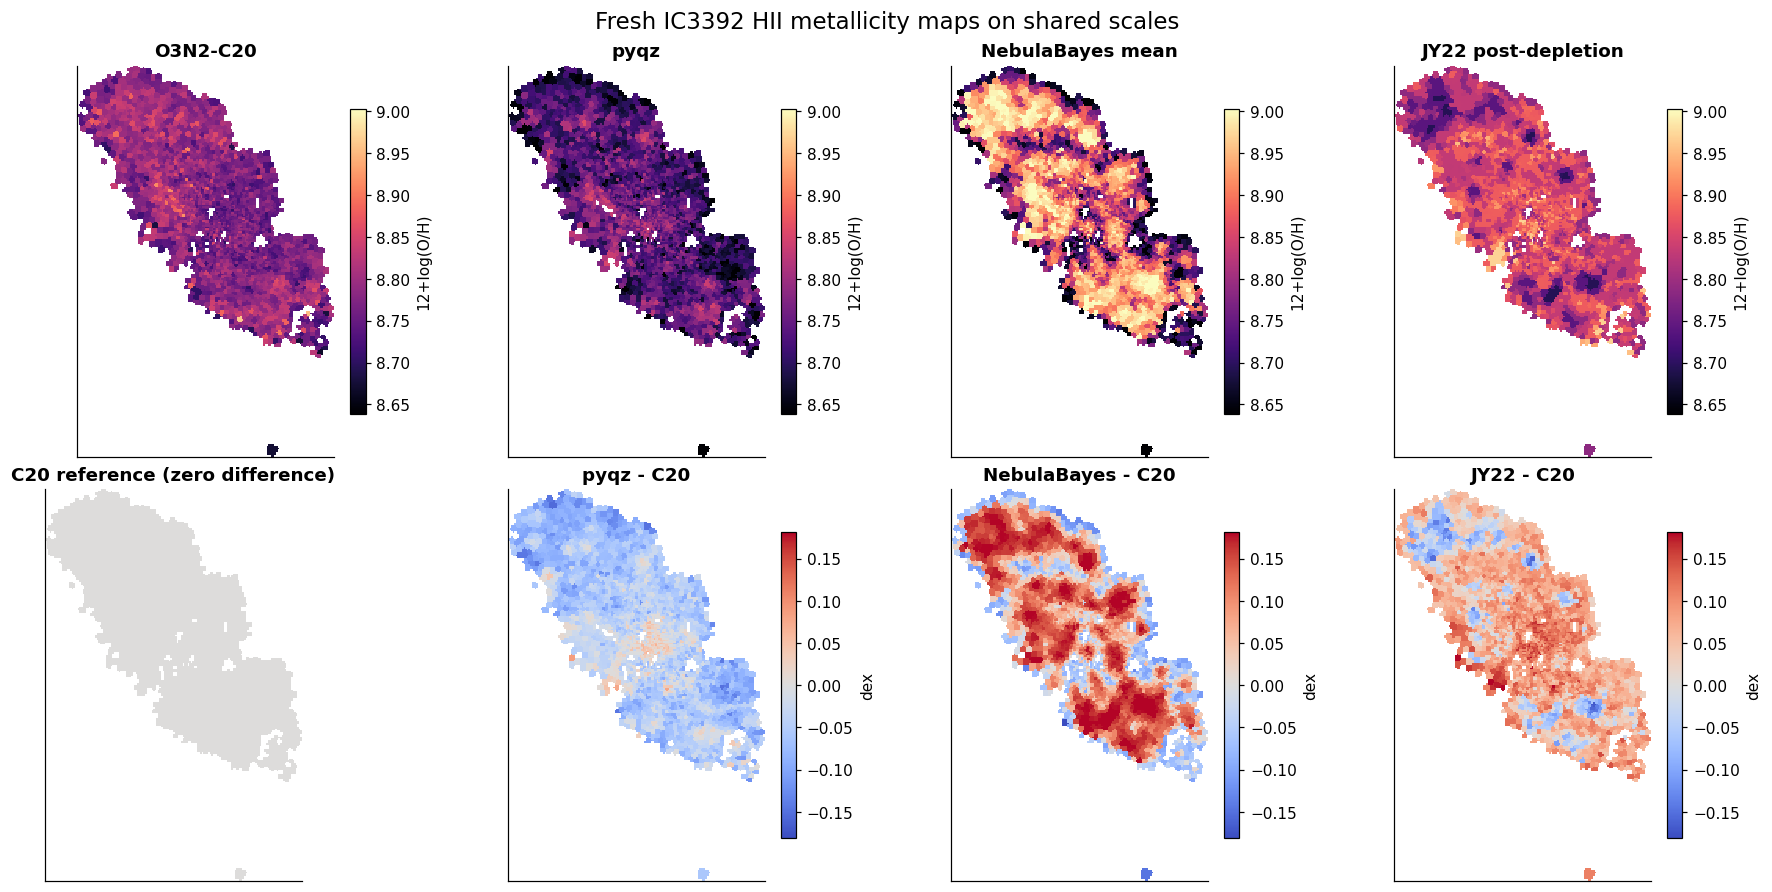

In [4]:
abundance_arrays = [c20] + [bin_df[name].to_numpy(float) for name in method_hdus.values()]
abundance_values = np.concatenate([values[np.isfinite(values)] for values in abundance_arrays])
abundance_vmin, abundance_vmax = np.percentile(abundance_values, (1, 99))
differences = {
    method: kept_maps[name] - kept_maps[reference_hdus["C20"]]
    for method, name in method_hdus.items()
}
difference_values = np.concatenate(
    [np.abs(values[np.isfinite(values)]) for values in differences.values()]
)
difference_limit = np.percentile(difference_values, 98)

fig, axes = plt.subplots(2, 4, figsize=(16, 8), constrained_layout=True)
top_maps = [
    ("O3N2-C20", kept_maps[reference_hdus["C20"]]),
    ("pyqz", kept_maps[method_hdus["pyqz"]]),
    ("NebulaBayes mean", kept_maps[method_hdus["NebulaBayes"]]),
    ("JY22 post-depletion", kept_maps[method_hdus["JY22"]]),
]
for ax, (title, image) in zip(axes[0], top_maps, strict=True):
    artist = robust_map(
        ax, image, title, cmap="magma", vmin=abundance_vmin, vmax=abundance_vmax
    )
    fig.colorbar(artist, ax=ax, shrink=0.78, label="12+log(O/H)")
robust_map(
    axes[1, 0],
    np.where(np.isfinite(kept_maps[reference_hdus["C20"]]), 0.0, np.nan),
    "C20 reference (zero difference)",
    cmap="coolwarm",
    vmin=-difference_limit,
    vmax=difference_limit,
)
for ax, method in zip(axes[1, 1:], method_hdus, strict=True):
    artist = robust_map(
        ax,
        differences[method],
        f"{method} - C20",
        cmap="coolwarm",
        vmin=-difference_limit,
        vmax=difference_limit,
    )
    fig.colorbar(artist, ax=ax, shrink=0.78, label="dex")
fig.suptitle("Fresh IC3392 HII metallicity maps on shared scales", fontsize=15)
None

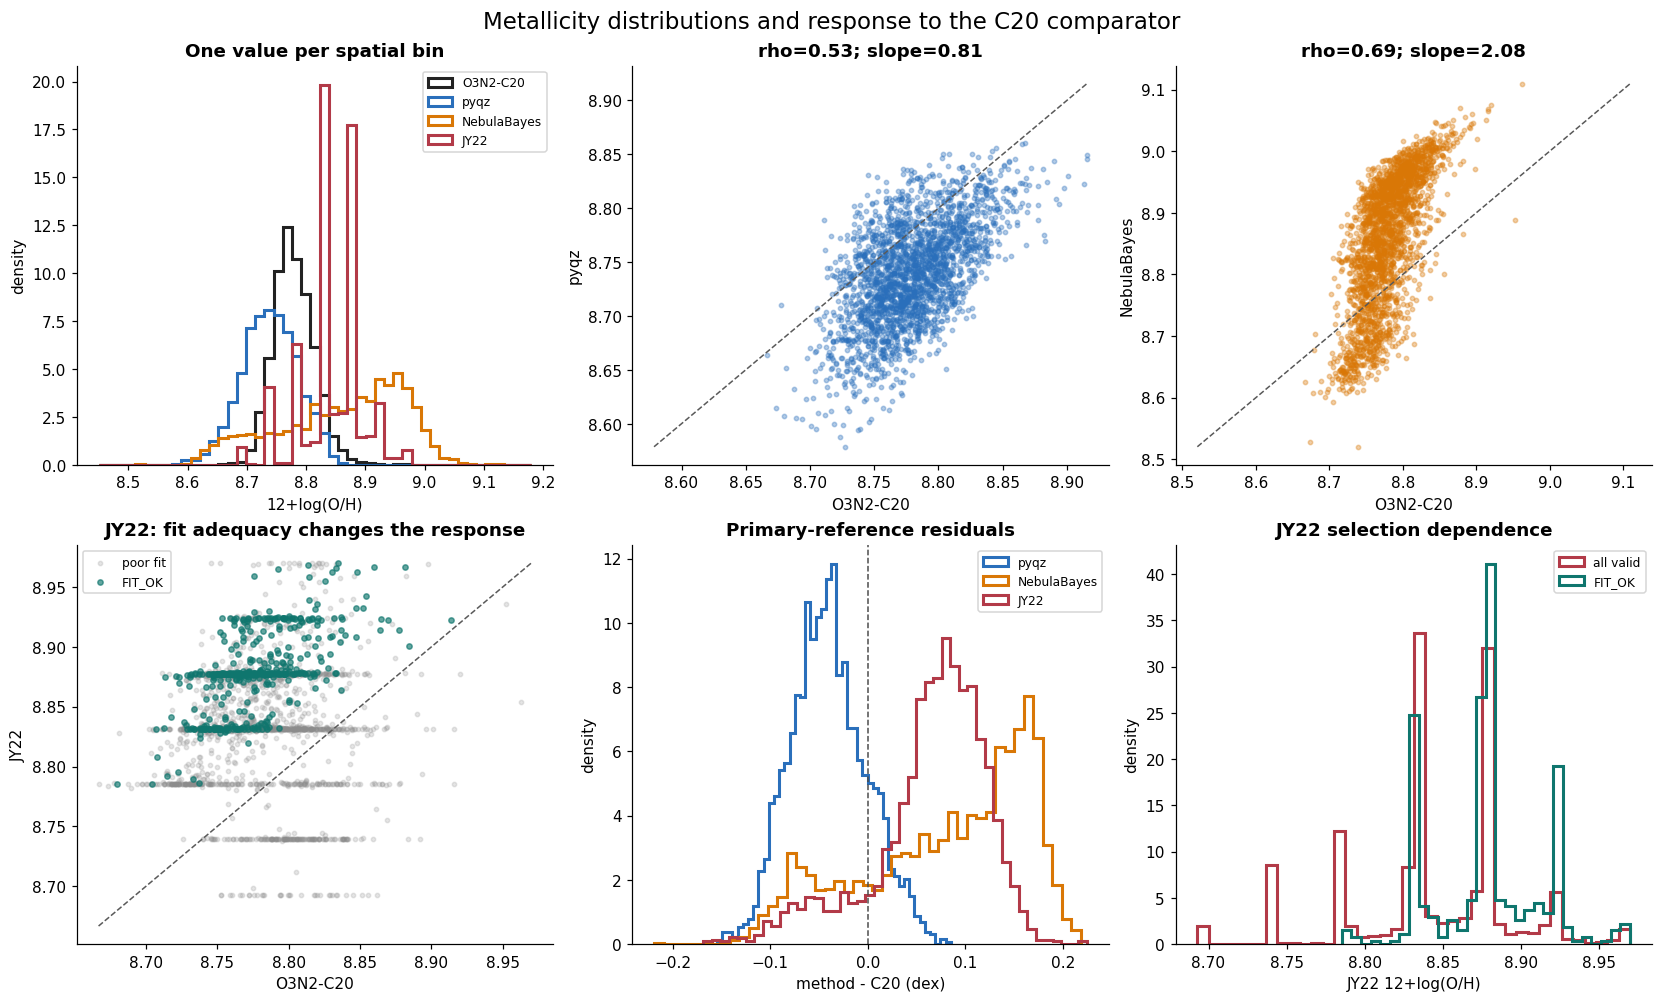

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)
histogram_series = [("O3N2-C20", c20[np.isfinite(c20)])]
histogram_series += [
    (method, bin_df.loc[method_masks[method], hdu_name].to_numpy(float))
    for method, hdu_name in method_hdus.items()
]
bins = np.linspace(8.45, 9.18, 48)
for label, values in histogram_series:
    axes[0, 0].hist(
        values,
        bins=bins,
        density=True,
        histtype="step",
        lw=2,
        label=label,
        color=METHOD_COLORS.get(label, None),
    )
axes[0, 0].set(xlabel="12+log(O/H)", ylabel="density", title="One value per spatial bin")
axes[0, 0].legend(fontsize=8)

for ax, method in zip(axes[0, 1:], ("pyqz", "NebulaBayes"), strict=True):
    values = bin_df[method_hdus[method]].to_numpy(float)
    keep = method_masks[method] & np.isfinite(c20) & np.isfinite(values)
    ax.scatter(c20[keep], values[keep], s=8, alpha=0.35, color=METHOD_COLORS[method], rasterized=True)
    limits = [min(c20[keep].min(), values[keep].min()), max(c20[keep].max(), values[keep].max())]
    ax.plot(limits, limits, "--", color="0.35", lw=1)
    ax.set(
        xlabel="O3N2-C20",
        ylabel=method,
        title=f"rho={comparison_to_c20.loc[method, 'Spearman rho']:.2f}; slope={comparison_to_c20.loc[method, 'OLS slope']:.2f}",
    )

jy = bin_df[method_hdus["JY22"]].to_numpy(float)
jy_keep = method_masks["JY22"] & np.isfinite(c20) & np.isfinite(jy)
axes[1, 0].scatter(c20[jy_keep & ~jy_fit_all], jy[jy_keep & ~jy_fit_all], s=8, alpha=0.22, color="0.55", label="poor fit", rasterized=True)
axes[1, 0].scatter(c20[jy_keep & jy_fit_all], jy[jy_keep & jy_fit_all], s=12, alpha=0.65, color=METHOD_COLORS["JY22 FIT_OK"], label="FIT_OK", rasterized=True)
limits = [min(c20[jy_keep].min(), jy[jy_keep].min()), max(c20[jy_keep].max(), jy[jy_keep].max())]
axes[1, 0].plot(limits, limits, "--", color="0.35", lw=1)
axes[1, 0].set(xlabel="O3N2-C20", ylabel="JY22", title="JY22: fit adequacy changes the response")
axes[1, 0].legend(fontsize=8)

for method, color in (("pyqz", METHOD_COLORS["pyqz"]), ("NebulaBayes", METHOD_COLORS["NebulaBayes"]), ("JY22", METHOD_COLORS["JY22"])):
    values = bin_df[method_hdus[method]].to_numpy(float)
    keep = method_masks[method] & np.isfinite(c20) & np.isfinite(values)
    axes[1, 1].hist(values[keep] - c20[keep], bins=45, density=True, histtype="step", lw=2, label=method, color=color)
axes[1, 1].axvline(0, color="0.3", ls="--", lw=1)
axes[1, 1].set(xlabel="method - C20 (dex)", ylabel="density", title="Primary-reference residuals")
axes[1, 1].legend(fontsize=8)

axes[1, 2].hist(jy[jy_keep], bins=38, density=True, histtype="step", lw=2, color=METHOD_COLORS["JY22"], label="all valid")
axes[1, 2].hist(jy[jy_keep & jy_fit_all], bins=30, density=True, histtype="step", lw=2, color=METHOD_COLORS["JY22 FIT_OK"], label="FIT_OK")
axes[1, 2].set(xlabel="JY22 12+log(O/H)", ylabel="density", title="JY22 selection dependence")
axes[1, 2].legend(fontsize=8)
fig.suptitle("Metallicity distributions and response to the C20 comparator", fontsize=15)
None

The visual improvement is real, but the three methods do not have identical scientific behaviour. pyqz tracks C20 moderately well with a small negative median offset. NebulaBayes is continuous and correlated with C20, but has a substantially larger abundance response. JY22's *marginal histogram* no longer has the old zero-point problem; its weak all-bin spatial response is instead concentrated in bins that its own model rejects.

## 3. Secondary calibration sensitivity

These comparisons are performed after the C20 result, not used to tune a model. D16, PG16, and M13 encode different line-ratio responses and abundance scales, so disagreement can reflect calibration physics rather than a software defect.

n  median delta  Spearman rho  OLS slope  range ratio
method      reference                                                          
pyqz        C20        2394       -0.0419        0.5325     0.8065       1.3840
            D16        2394       -0.0610        0.5611     0.4475       0.7699
            PG16       2394        0.1906        0.3659     0.5028       1.4781
            M13        2394        0.1688        0.5325     0.7251       1.2450
NebulaBayes C20        2403        0.1010        0.6920     2.0828       2.6967
            D16        2404        0.0721       -0.3195    -0.4765       1.5246
            PG16       2404        0.3290       -0.5564    -1.7349       2.9349
            M13        2401        0.3118        0.6920     1.8900       2.4349
JY22        C20        2403        0.0753        0.1214     0.1044       1.4057
            D16        2404        0.0536        0.5820     0.4821       0.8050
            PG16       2404        0.3040        0.4667     0.6824       1.5496
            M13        2401        0.2871        0.1202     0.0853       1.2672

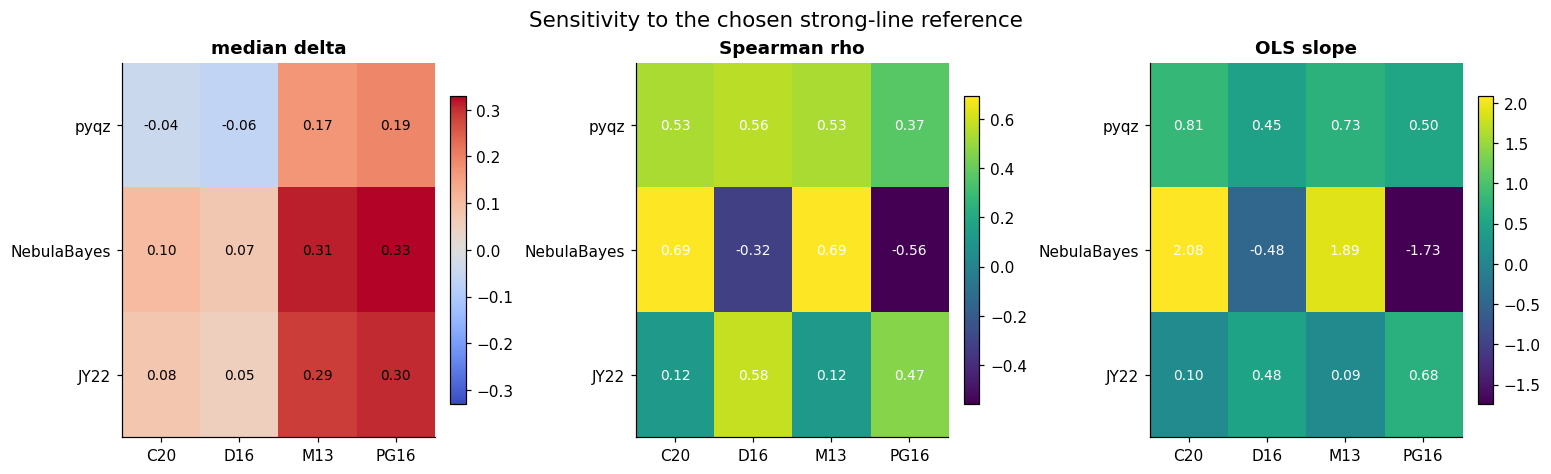

In [6]:
secondary_rows = []
for method, method_name in method_hdus.items():
    for reference_label, reference_name in reference_hdus.items():
        row = comparison_summary(
            bin_df[reference_name], bin_df[method_name], method_masks[method]
        )
        secondary_rows.append(
            {
                "method": method,
                "reference": reference_label,
                "n": row["n"],
                "median delta": row["median delta"],
                "Spearman rho": row["Spearman rho"],
                "OLS slope": row["OLS slope"],
                "range ratio": row["range ratio"],
            }
        )
secondary_comparisons = pd.DataFrame(secondary_rows).set_index(["method", "reference"])
display(secondary_comparisons.round(4))

metric_names = ("median delta", "Spearman rho", "OLS slope")
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), constrained_layout=True)
for ax, metric in zip(axes, metric_names, strict=True):
    matrix = secondary_comparisons[metric].unstack("reference").loc[list(method_hdus)]
    if metric == "median delta":
        limit = np.nanmax(np.abs(matrix.to_numpy()))
        artist = ax.imshow(matrix, cmap="coolwarm", norm=TwoSlopeNorm(vcenter=0, vmin=-limit, vmax=limit), aspect="auto")
    else:
        artist = ax.imshow(matrix, cmap="viridis", aspect="auto")
    ax.set_xticks(range(len(matrix.columns)), matrix.columns)
    ax.set_yticks(range(len(matrix.index)), matrix.index)
    ax.set_title(metric)
    for row_index in range(matrix.shape[0]):
        for column_index in range(matrix.shape[1]):
            ax.text(column_index, row_index, f"{matrix.iloc[row_index, column_index]:.2f}", ha="center", va="center", color="white" if metric != "median delta" else "black", fontsize=9)
    fig.colorbar(artist, ax=ax, shrink=0.82)
fig.suptitle("Sensitivity to the chosen strong-line reference", fontsize=14)
None

O3N2-C20 and O3N2-M13 have nearly identical rank ordering but differ by a median 0.212 dex, exactly the distinction needed when comparing to Peng et al. D16 and PG16 can give quite different rank responses, especially for NebulaBayes. Therefore “agreement with one strong-line calibration” is not a sufficient validation criterion; method-specific fit diagnostics remain essential.

## 4. pyqz auxiliary products

`PYQZ_VALID` is the finite-result indicator. `PYQZ_FLAG` is retained as the raw package flag and is not decoded as a simple success/failure bitmask. The off-grid percentage reports Monte Carlo realisations outside the diagnostic grid and should be inspected explicitly.

Invalid evaluated BIN_IDs: [7, 200, 350, 418, 492, 526, 568, 680, 1097, 2502]


,value
evaluated HII bins,2404.000000
valid HII bins,2394.000000
valid/evaluated,0.995840
median O/H KDE error,0.045193
p98 O/H KDE error,0.100807
median off-grid percent,0.000000
p98 off-grid percent,18.514000
fraction with off-grid >10%,0.042189
maximum off-grid percent,47.000000
max |logq-logu-log10(c)|,0.000000


**Raw pyqz flag distribution among evaluated bins**

,count,fraction
8,10,0.0042
13,2393,0.9954
134,1,0.0004


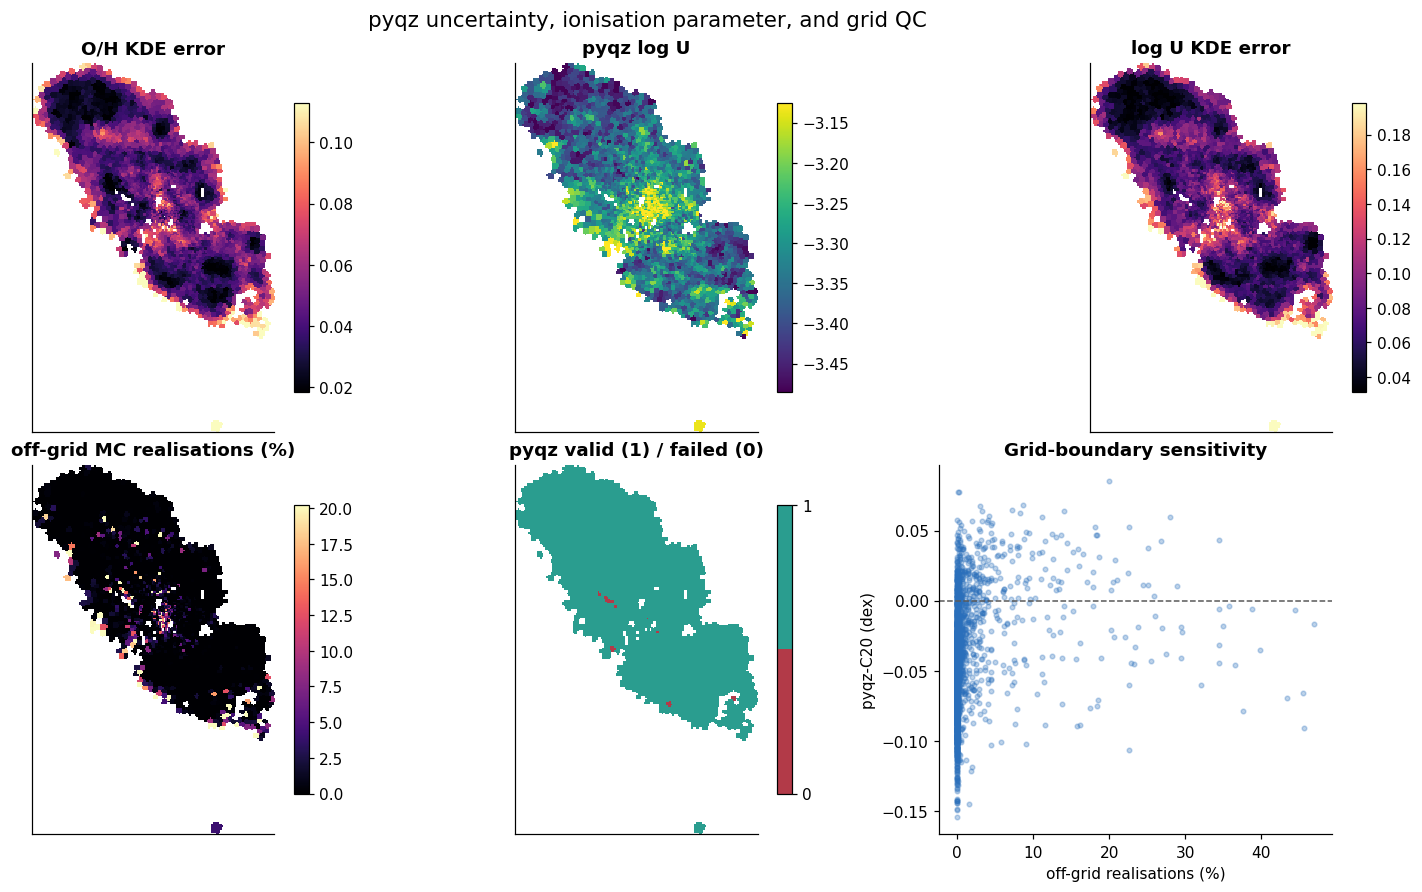

In [7]:
py_valid_values = bin_df["PYQZ_VALID_HII"].to_numpy(int)
py_evaluated = py_valid_values != -99
py_valid = py_valid_values == 1
py_offgrid = bin_df["PYQZ_RS_OFFGRID_HII"].to_numpy(float)
py_oh_error = bin_df["O_H_PYQZ_HII_ERR"].to_numpy(float)
py_logq = bin_df["LOG_Q_PYQZ_HII"].to_numpy(float)
py_logu = bin_df["LOG_U_PYQZ_HII"].to_numpy(float)

pyqz_summary = pd.DataFrame(
    {
        "value": {
            "evaluated HII bins": py_evaluated.sum(),
            "valid HII bins": py_valid.sum(),
            "valid/evaluated": py_valid[py_evaluated].mean(),
            "median O/H KDE error": np.nanmedian(py_oh_error[py_valid]),
            "p98 O/H KDE error": np.nanpercentile(py_oh_error[py_valid], 98),
            "median off-grid percent": np.nanmedian(py_offgrid[py_valid]),
            "p98 off-grid percent": np.nanpercentile(py_offgrid[py_valid], 98),
            "fraction with off-grid >10%": np.mean(py_offgrid[py_valid] > 10),
            "maximum off-grid percent": np.nanmax(py_offgrid[py_valid]),
            "max |logq-logu-log10(c)|": np.nanmax(np.abs(py_logq[py_valid] - py_logu[py_valid] - LOG10_C_CM_S)),
        }
    }
)
display(pyqz_summary)
display(Markdown("**Raw pyqz flag distribution among evaluated bins**"))
display(flag_counts(bin_df["PYQZ_FLAG_HII"], py_evaluated).round(4))
print("Invalid evaluated BIN_IDs:", bin_df.index[py_evaluated & ~py_valid].tolist())

fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
map_specs = [
    ("O_H_PYQZ_HII_ERR", "O/H KDE error", "magma"),
    ("LOG_U_PYQZ_HII", "pyqz log U", "viridis"),
    ("LOG_U_PYQZ_HII_ERR", "log U KDE error", "magma"),
    ("PYQZ_RS_OFFGRID_HII", "off-grid MC realisations (%)", "magma"),
]
for ax, (name, title, cmap) in zip(axes.ravel()[:4], map_specs, strict=True):
    artist = robust_map(ax, kept_maps[name], title, cmap=cmap)
    fig.colorbar(artist, ax=ax, shrink=0.78)
valid_display = np.where(kept_maps["PYQZ_VALID_HII"] == 1, 1.0, np.where(kept_maps["PYQZ_VALID_HII"] == 0, 0.0, np.nan))
artist = robust_map(axes[1, 1], valid_display, "pyqz valid (1) / failed (0)", cmap=ListedColormap(["#B23A48", "#2A9D8F"]), vmin=0, vmax=1)
fig.colorbar(artist, ax=axes[1, 1], shrink=0.78, ticks=[0, 1])
py_delta = bin_df[method_hdus["pyqz"]].to_numpy(float) - c20
keep = py_valid & np.isfinite(py_delta) & np.isfinite(py_offgrid)
axes[1, 2].scatter(py_offgrid[keep], py_delta[keep], s=9, alpha=0.3, color=METHOD_COLORS["pyqz"], rasterized=True)
axes[1, 2].axhline(0, color="0.35", ls="--", lw=1)
axes[1, 2].set(xlabel="off-grid realisations (%)", ylabel="pyqz-C20 (dex)", title="Grid-boundary sensitivity")
fig.suptitle("pyqz uncertainty, ionisation parameter, and grid QC", fontsize=14)
None

pyqz is the healthiest of the three spatial products in this rerun: 99.58% of evaluated HII bins are valid, the log-q/log-U conversion is exact, and only 4.22% of valid bins have more than 10% off-grid realisations. The ten failed bins should remain masked. No IC3392 map-level production change is indicated, although the integrated pyqz result is checked separately below.

## 5. NebulaBayes: continuity fixed, pressure still boundary-limited

The public central maps now store marginal-posterior means. Explicit `*_MODE` companions retain the package's sampled grid-node modes. Reliability is parameter-specific: a valid joint numerical result does not imply that log(P/k) has a closed, interior posterior.

In [8]:
nb_valid_values = bin_df["NB_VALID_HII"].to_numpy(int)
nb_evaluated = nb_valid_values != -99
nb_valid = nb_valid_values == 1
nb_flag = bin_df["NB_FLAG_HII"].to_numpy(int)
nb_oh_reliable = bin_df["NB_OH_RELIABLE_HII"].to_numpy(int) == 1
nb_logu_reliable = bin_df["NB_LOGU_RELIABLE_HII"].to_numpy(int) == 1
nb_logpk_reliable = bin_df["NB_LOGPK_RELIABLE_HII"].to_numpy(int) == 1
nb_all_reliable = nb_oh_reliable & nb_logu_reliable & nb_logpk_reliable
nb_mean = bin_df["O_H_NEBULABAYES_HII"].to_numpy(float)
nb_mode = bin_df["O_H_NEBULABAYES_HII_MODE"].to_numpy(float)
nb_oh_width = (
    bin_df["O_H_NEBULABAYES_HII_CI68_HIGH"].to_numpy(float)
    - bin_df["O_H_NEBULABAYES_HII_CI68_LOW"].to_numpy(float)
)
nb_logpk_width = (
    bin_df["LOG_PK_NEBULABAYES_HII_CI68_HIGH"].to_numpy(float)
    - bin_df["LOG_PK_NEBULABAYES_HII_CI68_LOW"].to_numpy(float)
)

nb_summary = pd.DataFrame(
    {
        "value": {
            "evaluated HII bins": nb_evaluated.sum(),
            "valid HII bins": nb_valid.sum(),
            "O/H reliable fraction": nb_oh_reliable[nb_evaluated].mean(),
            "log U reliable fraction": nb_logu_reliable[nb_evaluated].mean(),
            "log P/k reliable fraction": nb_logpk_reliable[nb_evaluated].mean(),
            "all three reliable fraction": nb_all_reliable[nb_evaluated].mean(),
            "O/H mean unique values (1e-8 dex)": np.unique(np.round(nb_mean[nb_valid], 8)).size,
            "O/H sampled-mode unique values": np.unique(np.round(nb_mode[nb_valid], 8)).size,
            "median |mean-mode| (dex)": np.median(np.abs(nb_mean[nb_valid] - nb_mode[nb_valid])),
            "median O/H CI68 width (dex)": np.nanmedian(nb_oh_width[nb_valid]),
            "median finite log P/k CI68 width": np.nanmedian(nb_logpk_width[nb_valid]),
            "fraction with n_localmax > 1": np.mean(bin_df.loc[nb_evaluated, "NB_NLOCALMAX_HII"] > 1),
        }
    }
)
nb_bits = pd.DataFrame(
    {
        "fraction of evaluated bins": {
            "O/H edge": np.mean((nb_flag[nb_evaluated] & NB_FLAG_OH_EDGE) != 0),
            "log U edge": np.mean((nb_flag[nb_evaluated] & NB_FLAG_LOGU_EDGE) != 0),
            "log P/k edge": np.mean((nb_flag[nb_evaluated] & NB_FLAG_LOGPK_EDGE) != 0),
            "open/non-finite CI68": np.mean((nb_flag[nb_evaluated] & NB_FLAG_OPEN_CI68) != 0),
            "exception": np.mean((nb_flag[nb_evaluated] & NB_FLAG_EXCEPTION) != 0),
        }
    }
)
display(nb_summary)
display(nb_bits.round(4))
display(Markdown("**NebulaBayes combined flag distribution**"))
display(flag_counts(nb_flag, nb_evaluated).round(4))

nb_delta = nb_mean - c20
nb_pair = nb_valid & np.isfinite(nb_delta)
pressure_split = pd.DataFrame(
    {
        "n": {
            "pressure reliable": np.sum(nb_pair & nb_logpk_reliable),
            "pressure unreliable": np.sum(nb_pair & ~nb_logpk_reliable),
        },
        "median NB-C20": {
            "pressure reliable": np.median(nb_delta[nb_pair & nb_logpk_reliable]),
            "pressure unreliable": np.median(nb_delta[nb_pair & ~nb_logpk_reliable]),
        },
        "median O/H CI width": {
            "pressure reliable": np.nanmedian(nb_oh_width[nb_pair & nb_logpk_reliable]),
            "pressure unreliable": np.nanmedian(nb_oh_width[nb_pair & ~nb_logpk_reliable]),
        },
    }
)
display(pressure_split.round(4))

,value
evaluated HII bins,2404.000000
valid HII bins,2404.000000
O/H reliable fraction,1.000000
log U reliable fraction,1.000000
log P/k reliable fraction,0.444676
all three reliable fraction,0.444676
O/H mean unique values (1e-8 dex),2404.000000
O/H sampled-mode unique values,32.000000
median |mean-mode| (dex),0.010247
median O/H CI68 width (dex),0.126962


,fraction of evaluated bins
O/H edge,0.0000
log U edge,0.0000
log P/k edge,0.5553
open/non-finite CI68,0.3706
exception,0.0000


**NebulaBayes combined flag distribution**

,count,fraction
0,1069,0.4447
4,444,0.1847
12,891,0.3706


,n,median NB-C20,median O/H CI width
pressure reliable,1068,0.0111,0.1834
pressure unreliable,1335,0.1449,0.0846


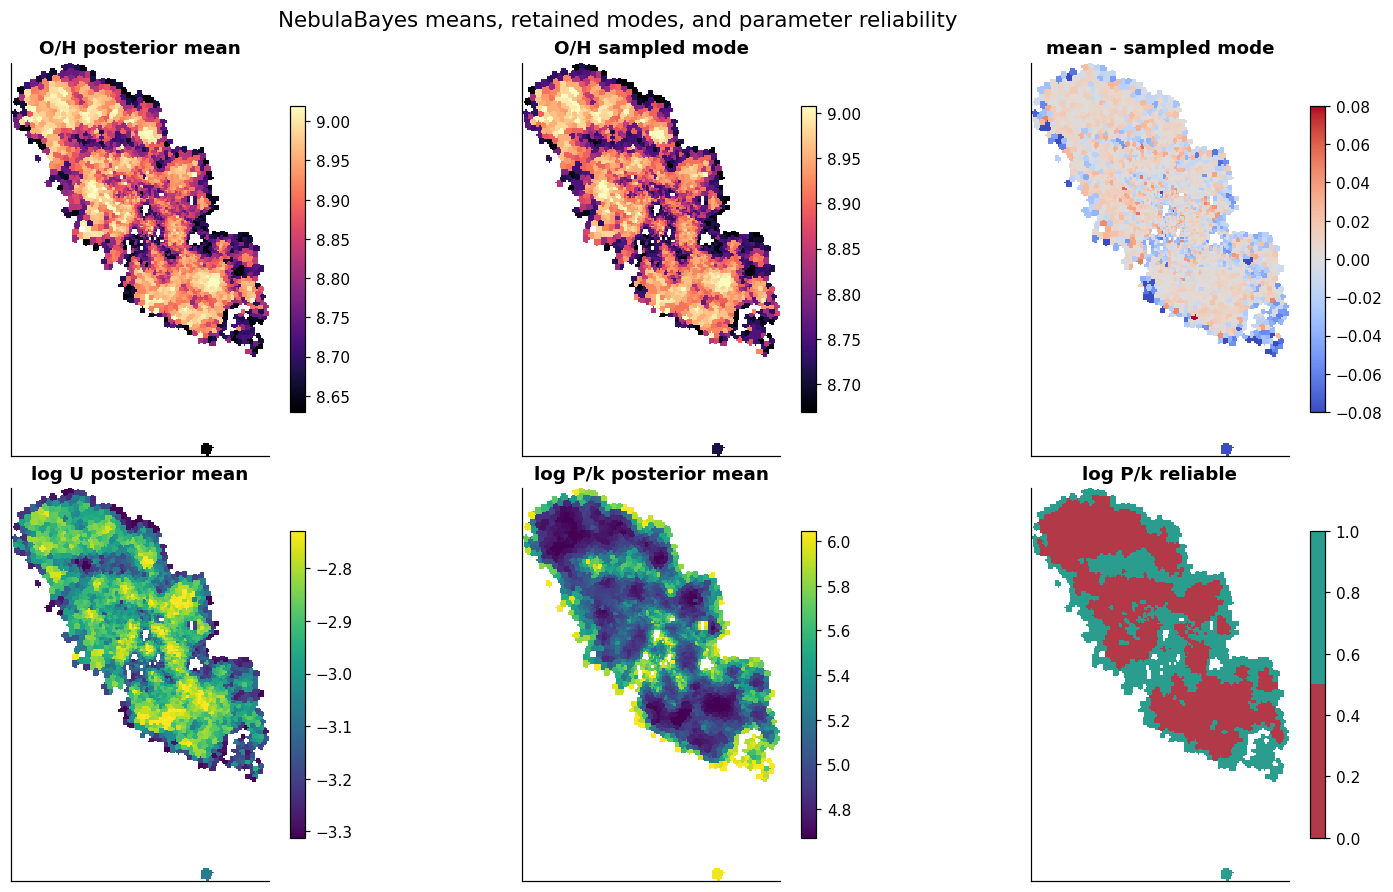

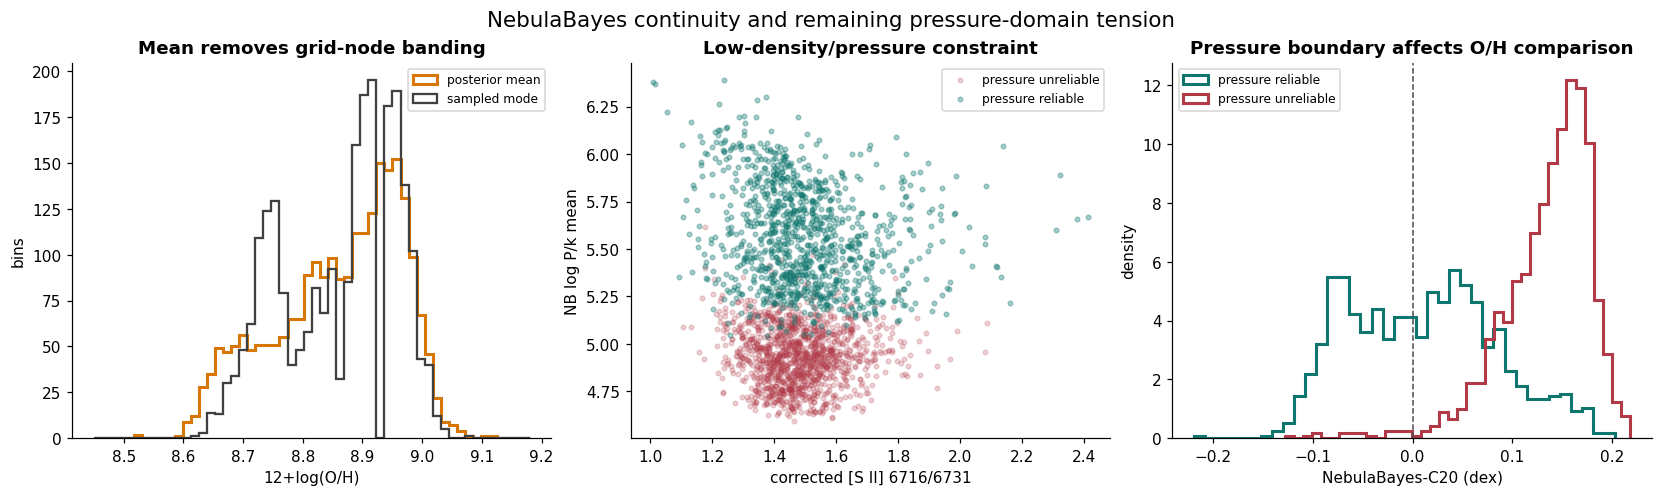

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
nb_map_specs = [
    ("O_H_NEBULABAYES_HII", "O/H posterior mean", "magma"),
    ("O_H_NEBULABAYES_HII_MODE", "O/H sampled mode", "magma"),
    (None, "mean - sampled mode", "coolwarm"),
    ("LOG_U_NEBULABAYES_HII", "log U posterior mean", "viridis"),
    ("LOG_PK_NEBULABAYES_HII", "log P/k posterior mean", "viridis"),
    ("NB_LOGPK_RELIABLE_HII", "log P/k reliable", "RdYlGn"),
]
for ax, (name, title, cmap) in zip(axes.ravel(), nb_map_specs, strict=True):
    if name is None:
        image = kept_maps["O_H_NEBULABAYES_HII"] - kept_maps["O_H_NEBULABAYES_HII_MODE"]
        limit = np.nanpercentile(np.abs(image), 98)
        artist = robust_map(ax, image, title, cmap=cmap, vmin=-limit, vmax=limit)
    elif name == "NB_LOGPK_RELIABLE_HII":
        image = np.where(kept_maps[name] >= 0, kept_maps[name], np.nan)
        artist = robust_map(ax, image, title, cmap=ListedColormap(["#B23A48", "#2A9D8F"]), vmin=0, vmax=1)
    else:
        artist = robust_map(ax, kept_maps[name], title, cmap=cmap)
    fig.colorbar(artist, ax=ax, shrink=0.78)
fig.suptitle("NebulaBayes means, retained modes, and parameter reliability", fontsize=14)

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4.4), constrained_layout=True)
bins = np.linspace(8.45, 9.18, 55)
axes2[0].hist(nb_mean[nb_valid], bins=bins, histtype="step", lw=2, label="posterior mean", color=METHOD_COLORS["NebulaBayes"])
axes2[0].hist(nb_mode[nb_valid], bins=bins, histtype="step", lw=1.5, label="sampled mode", color="0.25")
axes2[0].set(xlabel="12+log(O/H)", ylabel="bins", title="Mean removes grid-node banding")
axes2[0].legend(fontsize=8)

sii_ratio = bin_df["SII6716_6730_CORR"].to_numpy(float)
logpk = bin_df["LOG_PK_NEBULABAYES_HII"].to_numpy(float)
keep = nb_valid & np.isfinite(sii_ratio) & np.isfinite(logpk)
axes2[1].scatter(sii_ratio[keep & ~nb_logpk_reliable], logpk[keep & ~nb_logpk_reliable], s=9, alpha=0.22, color=METHOD_COLORS["JY22"], label="pressure unreliable", rasterized=True)
axes2[1].scatter(sii_ratio[keep & nb_logpk_reliable], logpk[keep & nb_logpk_reliable], s=9, alpha=0.35, color=METHOD_COLORS["JY22 FIT_OK"], label="pressure reliable", rasterized=True)
axes2[1].set(xlabel="corrected [S II] 6716/6731", ylabel="NB log P/k mean", title="Low-density/pressure constraint")
axes2[1].legend(fontsize=8)

axes2[2].hist(nb_delta[nb_pair & nb_logpk_reliable], bins=38, density=True, histtype="step", lw=2, color=METHOD_COLORS["JY22 FIT_OK"], label="pressure reliable")
axes2[2].hist(nb_delta[nb_pair & ~nb_logpk_reliable], bins=38, density=True, histtype="step", lw=2, color=METHOD_COLORS["JY22"], label="pressure unreliable")
axes2[2].axvline(0, color="0.3", ls="--", lw=1)
axes2[2].set(xlabel="NebulaBayes-C20 (dex)", ylabel="density", title="Pressure boundary affects O/H comparison")
axes2[2].legend(fontsize=8)
fig2.suptitle("NebulaBayes continuity and remaining pressure-domain tension", fontsize=14)
None

The original NebulaBayes discreteness is fixed: all 2,404 valid HII bins have distinct posterior means at 1e-8 dex precision, whereas the retained package modes occupy only 32 O/H nodes. Increasing interpolation density is therefore not the missing remedy.

A separate issue remains. O/H and log U pass their parameter-specific reliability checks in every evaluated HII bin, but log(P/k) is reliable in only 44.47%; 55.53% touch the pressure edge and 37.06% have an open interval. The median NebulaBayes-C20 offset also differs between the pressure-reliable and pressure-unreliable subsets, so the pressure boundary should be included in metallicity sensitivity tests even though the O/H marginal itself is not flagged. For pressure science, use `NB_LOGPK_RELIABLE==1`; for a conservative joint-parameter sample, require `NB_FLAG==0`.

## 6. JY22: corrected abundance semantics, unresolved model-locus mismatch

The main JY22 abundance is now post-depletion gas-phase O/H. The explicit `PREDEP` map retains the native model-axis abundance. `VALID==1` means that the posterior calculation and stored summaries are finite; `FIT_OK==1` additionally requires minimum chi-square <= 9 for the nominal one degree of freedom. Grid-edge bits remain separate.

In [10]:
jy_valid_values = bin_df["JY22_VALID_HII"].to_numpy(int)
jy_evaluated = jy_valid_values != -99
jy_valid = jy_valid_values == 1
jy_fit = bin_df["JY22_FIT_OK_HII"].to_numpy(int) == 1
jy_flag = bin_df["JY22_FLAG_HII"].to_numpy(int)
jy_clean = jy_valid & (jy_flag == 0)
jy_oh = bin_df["O_H_JY22_HII"].to_numpy(float)
jy_pre = bin_df["O_H_JY22_PREDEP_HII"].to_numpy(float)
jy_chi2 = bin_df["JY22_CHI2_MIN_HII"].to_numpy(float)
jy_residual_norm = bin_df["JY22_RESID_NORM_HII"].to_numpy(float)
jy_oh_width = bin_df["O_H_JY22_HII_84"].to_numpy(float) - bin_df["O_H_JY22_HII_16"].to_numpy(float)
jy_logu_width = bin_df["LOG_U_JY22_HII_84"].to_numpy(float) - bin_df["LOG_U_JY22_HII_16"].to_numpy(float)

jy_summary = pd.DataFrame(
    {
        "value": {
            "evaluated HII bins": jy_evaluated.sum(),
            "numerically valid HII bins": jy_valid.sum(),
            "FIT_OK bins": np.sum(jy_fit & jy_evaluated),
            "FIT_OK/evaluated": np.mean(jy_fit[jy_evaluated]),
            "FLAG=0 clean bins": np.sum(jy_clean),
            "FLAG=0/evaluated": np.mean(jy_clean[jy_evaluated]),
            "median minimum chi-square": np.median(jy_chi2[jy_valid]),
            "median residual norm (dex)": np.median(jy_residual_norm[jy_valid]),
            "median O/H CI68 width (dex)": np.median(jy_oh_width[jy_valid]),
            "median log U CI68 width": np.median(jy_logu_width[jy_valid]),
            "median pre-minus-post O/H": np.median((jy_pre - jy_oh)[jy_valid]),
            "max |pre-post-0.22|": np.max(np.abs((jy_pre - jy_oh)[jy_valid] - 0.22)),
        }
    }
)
jy_bits = pd.DataFrame(
    {
        "fraction of evaluated bins": {
            "O/H edge": np.mean((jy_flag[jy_evaluated] & JY22_FLAG_OH_EDGE) != 0),
            "log U edge": np.mean((jy_flag[jy_evaluated] & JY22_FLAG_LOGU_EDGE) != 0),
            "posterior invalid": np.mean((jy_flag[jy_evaluated] & JY22_FLAG_POSTERIOR_INVALID) != 0),
            "covariance invalid": np.mean((jy_flag[jy_evaluated] & JY22_FLAG_COVARIANCE_INVALID) != 0),
            "exception": np.mean((jy_flag[jy_evaluated] & JY22_FLAG_EXCEPTION) != 0),
            "poor fit": np.mean((jy_flag[jy_evaluated] & JY22_FLAG_POOR_FIT) != 0),
        }
    }
)
display(jy_summary)
display(jy_bits.round(4))
display(Markdown("**JY22 combined flag distribution**"))
display(flag_counts(jy_flag, jy_evaluated).round(4))

residual_table = pd.DataFrame(
    {
        ratio: finite_summary(bin_df[f"JY22_RESID_{ratio}_HII"][jy_valid])
        for ratio in ("N2", "S2", "R3", "NORM")
    }
).T
display(residual_table.round(4))

,value
evaluated HII bins,2.404000e+03
numerically valid HII bins,2.404000e+03
FIT_OK bins,4.400000e+02
FIT_OK/evaluated,1.830283e-01
FLAG=0 clean bins,3.970000e+02
FLAG=0/evaluated,1.651414e-01
median minimum chi-square,5.331333e+01
median residual norm (dex),2.479583e-01
median O/H CI68 width (dex),3.163759e-02
median log U CI68 width,9.007903e-02


,fraction of evaluated bins
O/H edge,0.0175
log U edge,0.2966
posterior invalid,0.0000
covariance invalid,0.0000
exception,0.0000
poor fit,0.8170


**JY22 combined flag distribution**

,count,fraction
0,397,0.1651
1,11,0.0046
2,31,0.0129
3,1,0.0004
32,1254,0.5216
33,29,0.0121
34,680,0.2829
35,1,0.0004


,n,p02,p16,median,p84,p98,p98-p02
N2,2404.0,-0.0683,-0.0360,-0.0068,0.0519,0.1031,0.1714
S2,2404.0,-0.1124,-0.0447,-0.0083,0.0157,0.0326,0.1450
R3,2404.0,-1.0517,-0.5947,-0.1124,0.1930,0.3804,1.4322
NORM,2404.0,0.0222,0.0802,0.2480,0.6003,1.0574,1.0352


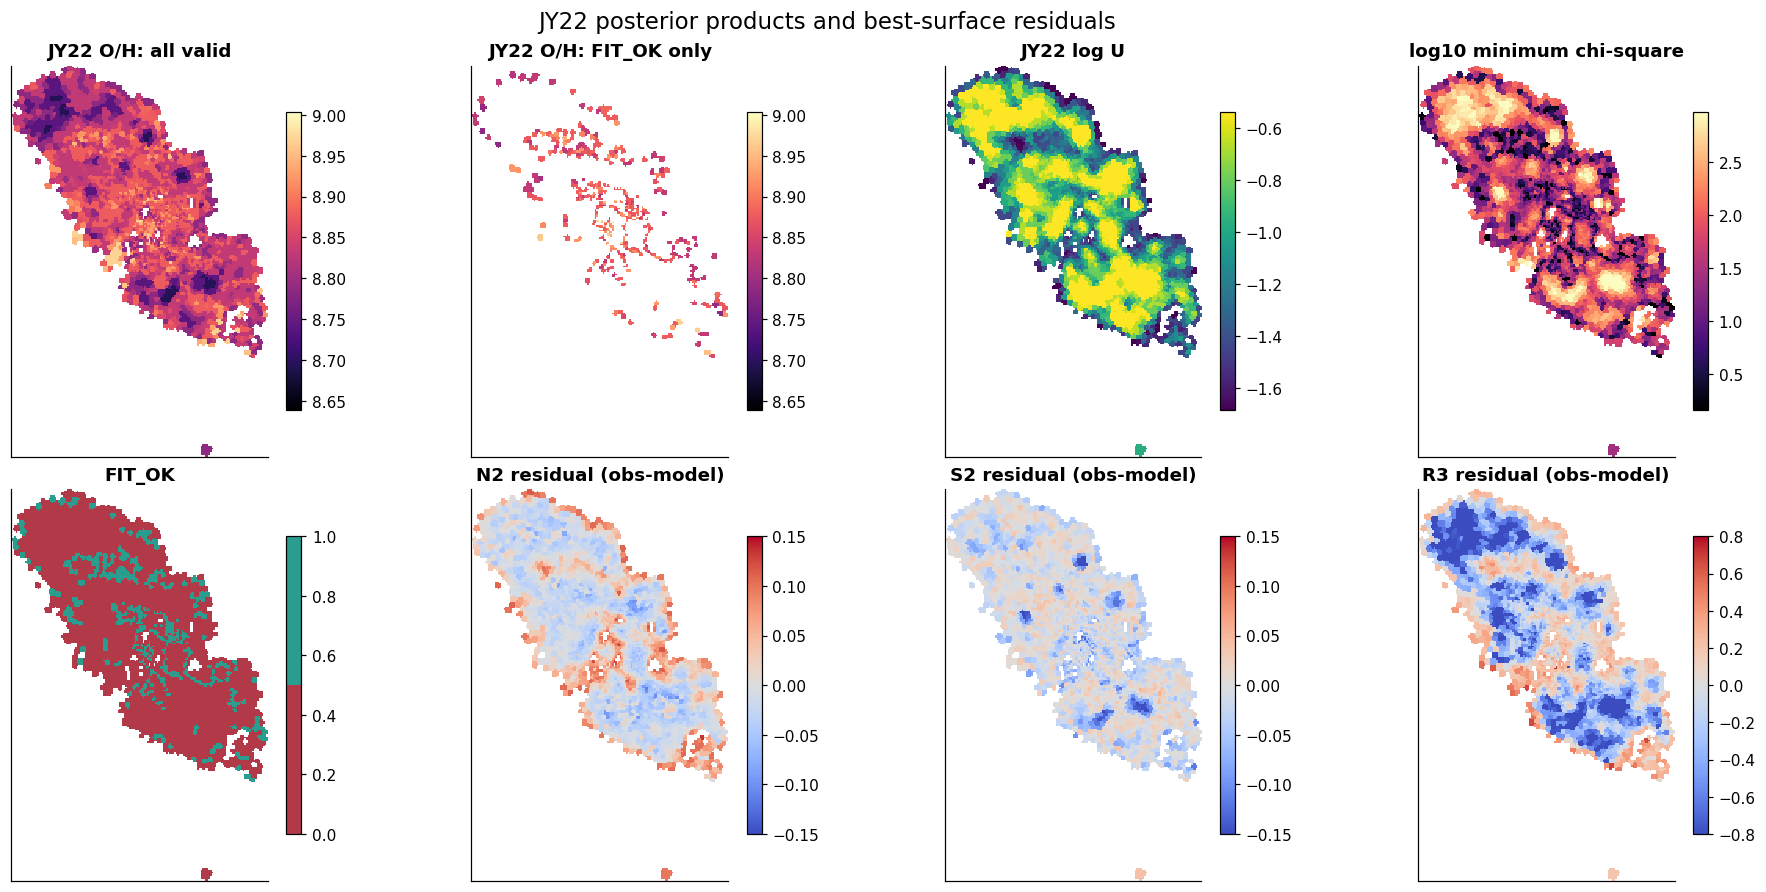

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(17, 8), constrained_layout=True)
jy_fit_map = np.where(kept_maps["JY22_FIT_OK_HII"] >= 0, kept_maps["JY22_FIT_OK_HII"], np.nan)
jy_oh_fit_map = np.where(kept_maps["JY22_FIT_OK_HII"] == 1, kept_maps["O_H_JY22_HII"], np.nan)
jy_map_specs = [
    (kept_maps["O_H_JY22_HII"], "JY22 O/H: all valid", "magma", abundance_vmin, abundance_vmax),
    (jy_oh_fit_map, "JY22 O/H: FIT_OK only", "magma", abundance_vmin, abundance_vmax),
    (kept_maps["LOG_U_JY22_HII"], "JY22 log U", "viridis", None, None),
    (np.log10(kept_maps["JY22_CHI2_MIN_HII"]), "log10 minimum chi-square", "magma", None, None),
    (jy_fit_map, "FIT_OK", ListedColormap(["#B23A48", "#2A9D8F"]), 0, 1),
    (kept_maps["JY22_RESID_N2_HII"], "N2 residual (obs-model)", "coolwarm", -0.15, 0.15),
    (kept_maps["JY22_RESID_S2_HII"], "S2 residual (obs-model)", "coolwarm", -0.15, 0.15),
    (kept_maps["JY22_RESID_R3_HII"], "R3 residual (obs-model)", "coolwarm", -0.8, 0.8),
]
for ax, (image, title, cmap, vmin, vmax) in zip(axes.ravel(), jy_map_specs, strict=True):
    artist = robust_map(ax, image, title, cmap=cmap, vmin=vmin, vmax=vmax)
    fig.colorbar(artist, ax=ax, shrink=0.76)
fig.suptitle("JY22 posterior products and best-surface residuals", fontsize=15)
None

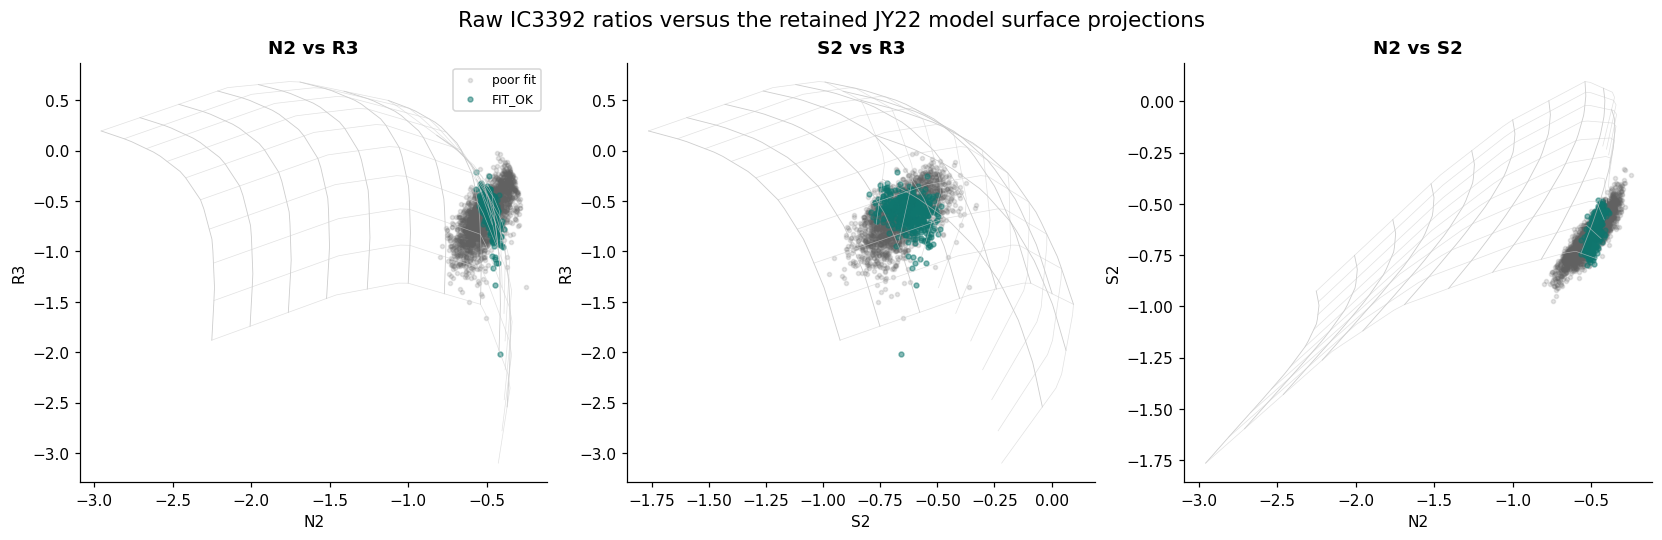

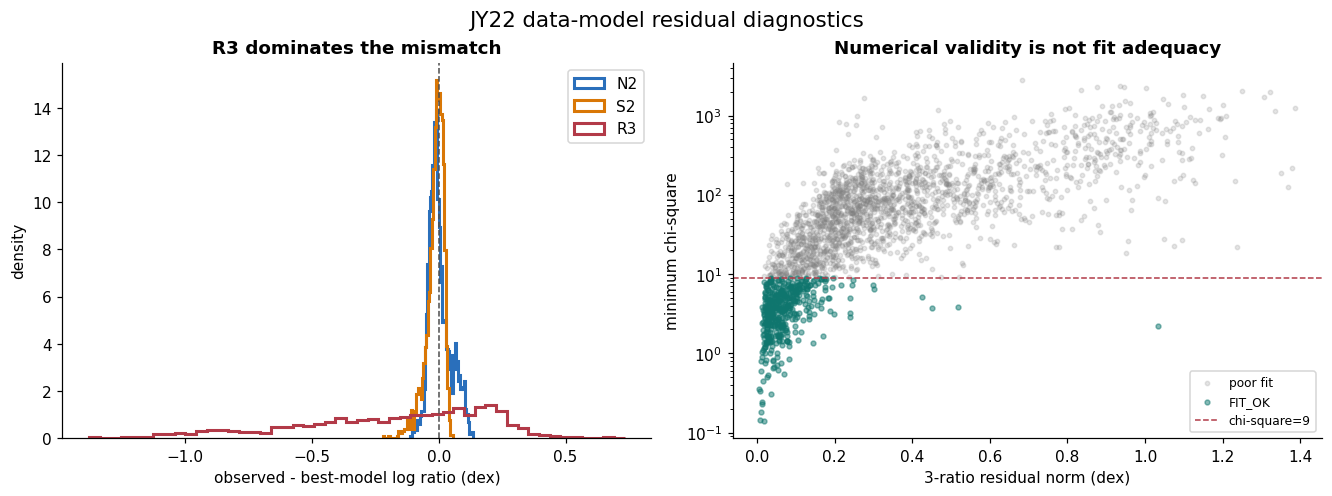

In [12]:
jy_grid = load_jy22_grid(GRID_PATH)
model_ratios = jy_grid.model_ratios
observed_ratios = bin_df[["RAW_N2", "RAW_S2", "RAW_R3"]].to_numpy(float)
ratio_labels = ("N2", "S2", "R3")
pair_specs = ((0, 2), (1, 2), (0, 1))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)
for ax, (x_index, y_index) in zip(axes, pair_specs, strict=True):
    for z_index in range(0, model_ratios.shape[0], 4):
        ax.plot(model_ratios[z_index, :, x_index], model_ratios[z_index, :, y_index], color="0.72", lw=0.55, alpha=0.7)
    for u_index in range(0, model_ratios.shape[1], 3):
        ax.plot(model_ratios[:, u_index, x_index], model_ratios[:, u_index, y_index], color="0.82", lw=0.45, alpha=0.65)
    poor = jy_valid & ~jy_fit
    good = jy_valid & jy_fit
    ax.scatter(observed_ratios[poor, x_index], observed_ratios[poor, y_index], s=7, alpha=0.16, color="0.38", label="poor fit", rasterized=True)
    ax.scatter(observed_ratios[good, x_index], observed_ratios[good, y_index], s=10, alpha=0.5, color=METHOD_COLORS["JY22 FIT_OK"], label="FIT_OK", rasterized=True)
    ax.set(xlabel=ratio_labels[x_index], ylabel=ratio_labels[y_index], title=f"{ratio_labels[x_index]} vs {ratio_labels[y_index]}")
axes[0].legend(fontsize=8)
fig.suptitle("Raw IC3392 ratios versus the retained JY22 model surface projections", fontsize=14)

fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4.4), constrained_layout=True)
residual_colors = {"N2": "#2A6FBB", "S2": "#D97706", "R3": "#B23A48"}
for ratio in ("N2", "S2", "R3"):
    values = bin_df.loc[jy_valid, f"JY22_RESID_{ratio}_HII"].to_numpy(float)
    axes2[0].hist(values, bins=50, density=True, histtype="step", lw=2, label=ratio, color=residual_colors[ratio])
axes2[0].axvline(0, color="0.3", ls="--", lw=1)
axes2[0].set(xlabel="observed - best-model log ratio (dex)", ylabel="density", title="R3 dominates the mismatch")
axes2[0].legend()
axes2[1].scatter(jy_residual_norm[jy_valid & ~jy_fit], jy_chi2[jy_valid & ~jy_fit], s=8, alpha=0.2, color="0.5", label="poor fit", rasterized=True)
axes2[1].scatter(jy_residual_norm[jy_valid & jy_fit], jy_chi2[jy_valid & jy_fit], s=10, alpha=0.5, color=METHOD_COLORS["JY22 FIT_OK"], label="FIT_OK", rasterized=True)
axes2[1].axhline(JY22_FORMAL_CHI2_MAX, color="#B23A48", ls="--", lw=1, label="chi-square=9")
axes2[1].set(xlabel="3-ratio residual norm (dex)", ylabel="minimum chi-square", yscale="log", title="Numerical validity is not fit adequacy")
axes2[1].legend(fontsize=8)
fig2.suptitle("JY22 data-model residual diagnostics", fontsize=14)
None

### Grid-density and log-U-domain falsification tests

Peng et al. state a -4 < log U < -0.5 parameter range and a 200 x 200 inference grid. The released archive contains a 40 x 40 interpolated surface over a wider log-U range; the production loader keeps 40 x 28 nodes inside the paper range. The fresh sensitivity test below resamples the released surface to 200 x 200 over the stated range. A second diagnostic uses the archive's full log-U range only to test whether the upper boundary is the cause; that experiment is **not method-faithful** and is not a proposed science product.

In [13]:
density_test = json.loads(DENSITY_TEST_PATH.read_text())
assert density_test["n_bins"] == int(jy_evaluated.sum())
grid_sensitivity = pd.DataFrame(
    [
        {
            "case": "production released nodes",
            "shape": "40 x 28",
            "method-faithful": True,
            "median chi-square": density_test["production_chi2_median"],
            "FIT_OK fraction": density_test["production_fit_ok_fraction"],
            "log-U edge fraction": density_test["production_logu_edge_fraction"],
            "median O/H change": 0.0,
        },
        {
            "case": "paper-density resampling",
            "shape": "200 x 200",
            "method-faithful": True,
            "median chi-square": density_test["paper200_chi2_median"],
            "FIT_OK fraction": density_test["paper200_fit_ok_fraction"],
            "log-U edge fraction": density_test["paper200_logu_edge_fraction"],
            "median O/H change": density_test["delta_oh_p02_p16_p50_p84_p98"][2],
        },
        {
            "case": "full archive log-U range",
            "shape": "40 x 40",
            "method-faithful": False,
            "median chi-square": density_test["diagnostic_full_logu"]["chi2_median"],
            "FIT_OK fraction": density_test["diagnostic_full_logu"]["fit_ok_fraction"],
            "log-U edge fraction": density_test["diagnostic_full_logu"]["logu_edge_fraction"],
            "median O/H change": density_test["diagnostic_full_logu"]["o_h_median"] - np.median(jy_oh[jy_valid]),
        },
    ]
).set_index("case")
display(grid_sensitivity.round(4))
print(
    "200x200 O/H change p02/p16/p50/p84/p98:",
    np.round(density_test["delta_oh_p02_p16_p50_p84_p98"], 5),
)
print(
    "Full-range diagnostic fraction with inferred log U > -0.5:",
    f"{density_test['diagnostic_full_logu']['logu_above_paper_limit_fraction']:.1%}",
)

200x200 O/H change p02/p16/p50/p84/p98: [-0.01646 -0.01039  0.00052  0.01212  0.02289]
Full-range diagnostic fraction with inferred log U > -0.5: 20.3%


,shape,method-faithful,median chi-square,FIT_OK fraction,log-U edge fraction,median O/H change
case,,,,,,
production released nodes,40 x 28,True,53.3133,0.1830,0.2966,0.0000
paper-density resampling,200 x 200,True,49.8526,0.2225,0.2280,0.0005
full archive log-U range,40 x 40,False,51.4140,0.1868,0.0000,0.0076


The fixed JY22 abundance semantics are working: pre-depletion minus post-depletion O/H is exactly 0.22 dex. The old approximately 0.3 dex C20 discrepancy has fallen to +0.075 dex in the all-valid spatial sample. However, only 440/2,404 HII bins (18.30%) satisfy the nominal fit test and only 397 (16.51%) have `FLAG==0`. Their median minimum chi-square is 53.3, and R3 is the largest residual dimension.

The 200 x 200 experiment changes median O/H by only +0.0005 dex and raises fit coverage only to 22.3%. Extending log U outside the paper range yields 18.7% fit coverage. Therefore neither numerical grid density nor the retained upper log-U node is the root fix. The remaining JY22 behaviour is a model-locus/applicability problem for these IC3392/MUSE bins under the adopted fixed density, abundance-pattern, SED, geometry, and formal-error assumptions. It should remain visible through `FIT_OK`, residual, and flag maps rather than being hidden by arbitrary error inflation.

## 7. HII/SF parity and coverage

The pipeline evaluates an HII subset and a broader SF subset. For bins present in both, all three deterministic abundance products should agree exactly because the underlying representative spectrum is the same.

In [14]:
region_rows = []
overlap_rows = []
for region in ("HII", "SF"):
    for method, hii_oh_name in method_hdus.items():
        oh_name = hii_oh_name.replace("_HII", f"_{region}")
        valid_name = valid_hdus[method].replace("_HII", f"_{region}")
        evaluated = bin_df[valid_name].to_numpy(int) != -99
        valid = bin_df[valid_name].to_numpy(int) == 1
        row = {
            "region": region,
            "method": method,
            "evaluated": evaluated.sum(),
            "valid": valid.sum(),
            "valid/evaluated": valid[evaluated].mean(),
            "median O/H": np.nanmedian(bin_df.loc[valid, oh_name]),
        }
        if method == "NebulaBayes":
            row["pressure reliable"] = np.mean(bin_df.loc[evaluated, f"NB_LOGPK_RELIABLE_{region}"] == 1)
        if method == "JY22":
            row["FIT_OK"] = np.mean(bin_df.loc[evaluated, f"JY22_FIT_OK_{region}"] == 1)
        region_rows.append(row)

for method, hii_name in method_hdus.items():
    sf_name = hii_name.replace("_HII", "_SF")
    hii_valid = bin_df[valid_hdus[method]].to_numpy(int) == 1
    sf_valid = bin_df[valid_hdus[method].replace("_HII", "_SF")].to_numpy(int) == 1
    overlap = hii_valid & sf_valid
    delta = bin_df.loc[overlap, hii_name].to_numpy(float) - bin_df.loc[overlap, sf_name].to_numpy(float)
    overlap_rows.append(
        {"method": method, "overlap bins": overlap.sum(), "maximum |HII-SF|": np.max(np.abs(delta)), "median HII-SF": np.median(delta)}
    )
region_summary = pd.DataFrame(region_rows).set_index(["region", "method"])
overlap_summary = pd.DataFrame(overlap_rows).set_index("method")
display(region_summary.round(4))
display(overlap_summary)
assert np.allclose(overlap_summary["maximum |HII-SF|"], 0.0)

evaluated  valid  valid/evaluated  median O/H  pressure reliable  FIT_OK
region method                                                                               
HII    pyqz              2404   2394           0.9958      8.7391                NaN     NaN
       NebulaBayes       2404   2404           1.0000      8.8796             0.4447     NaN
       JY22              2404   2404           1.0000      8.8346                NaN  0.1830
SF     pyqz              2679   2667           0.9955      8.7355                NaN     NaN
       NebulaBayes       2679   2679           1.0000      8.8579             0.5017     NaN
       JY22              2679   2679           1.0000      8.8317                NaN  0.1642

,overlap bins,maximum |HII-SF|,median HII-SF
method,,,
pyqz,2394,0.0,0.0
NebulaBayes,2404,0.0,0.0
JY22,2404,0.0,0.0


The HII and SF products are internally consistent on all overlapping bins. The broader SF sample reproduces the same main limitation: NebulaBayes pressure reliability is about one half, and JY22 fit coverage is only about one sixth. This is not an HII-mask broadcasting bug.

## 8. Rerun log and integrated-spectrum audit

Spatial-bin completion and integrated-spectrum inference are separate tests. A method can produce healthy spatial maps yet fail when one summed spectrum mixes many physical conditions and is forced onto a one-zone grid.

In [15]:
log_text = LOG_PATH.read_text(errors="replace")
log_lines = log_text.splitlines()
runtime_warning_count = log_text.count("RuntimeWarning")
traceback_count = log_text.count("Traceback (most recent call last)")
successful_completion = "finished in" in log_text and "Further file written" in log_text

integrated_lines = []
for index, line in enumerate(log_lines):
    if line.startswith("Integrated HII/SF model-grid results"):
        integrated_lines = log_lines[index : index + 9]
        break
assert len(integrated_lines) == 9

parsed_rows = []
region = None
for line in integrated_lines[1:]:
    stripped = line.strip()
    if stripped.startswith("HII:"):
        region = "HII"
    elif stripped.startswith("SF:"):
        region = "SF"
    elif stripped.startswith("pyqz:"):
        valid = int(re.search(r"valid=(\d+)", stripped).group(1))
        flag = int(re.search(r"flag=(-?\d+)", stripped).group(1))
        parsed_rows.append({"region": region, "method": "pyqz", "valid": valid, "fit/reliability": "invalid" if not valid else "finite", "flag": flag})
    elif stripped.startswith("NebulaBayes means:"):
        reliable = re.search(r"reliable=\(([^)]+)\)", stripped).group(1)
        valid = int(re.search(r"valid=(\d+)", stripped).group(1))
        flag = int(re.search(r"flag=(-?\d+)", stripped).group(1))
        parsed_rows.append({"region": region, "method": "NebulaBayes", "valid": valid, "fit/reliability": f"(O/H, logU, logP)=({reliable})", "flag": flag})
    elif stripped.startswith("JY22 gas"):
        valid = int(re.search(r"valid=(\d+)", stripped).group(1))
        fit_ok = int(re.search(r"fit_ok=(\d+)", stripped).group(1))
        flag = int(re.search(r"flag=(-?\d+)", stripped).group(1))
        chi2 = float(re.search(r"chi2_min=([0-9.e+\-]+)", stripped).group(1))
        parsed_rows.append({"region": region, "method": "JY22", "valid": valid, "fit/reliability": f"FIT_OK={fit_ok}; chi2={chi2:.3g}", "flag": flag})

log_qc = pd.DataFrame(
    {
        "value": {
            "RuntimeWarning entries": runtime_warning_count,
            "fatal traceback entries": traceback_count,
            "all 2679 pyqz bins completed": "pyqz bins: 2679/2679 spectra complete" in log_text,
            "all 2679 NebulaBayes bins completed": "NebulaBayes bins: 2679/2679 spectra complete" in log_text,
            "all 2679 JY22 bins completed": "JY22 bins: 2679/2679 spectra complete" in log_text,
            "output write and wrapper completion": successful_completion,
            "integrated pyqz UnboundLocalError": "UnboundLocalError" in log_text,
        }
    }
)
display(log_qc)
display(pd.DataFrame(parsed_rows).set_index(["region", "method"]))
display(Markdown("**Exact integrated model-grid block from the fresh log**\n\n```text\n" + "\n".join(integrated_lines) + "\n```"))

,value
RuntimeWarning entries,21
fatal traceback entries,0
all 2679 pyqz bins completed,True
all 2679 NebulaBayes bins completed,True
all 2679 JY22 bins completed,True
output write and wrapper completion,True
integrated pyqz UnboundLocalError,True


valid              fit/reliability  flag
region method                                               
HII    pyqz             0                      invalid   -99
       NebulaBayes      1  (O/H, logU, logP)=(1, 1, 0)    12
       JY22             1      FIT_OK=0; chi2=4.35e+05    32
SF     pyqz             0                      invalid  1234
       NebulaBayes      1  (O/H, logU, logP)=(1, 1, 0)    12
       JY22             1      FIT_OK=0; chi2=2.34e+05    32

**Exact integrated model-grid block from the fresh log**

```text
Integrated HII/SF model-grid results (common six-line raw aperture)
  HII: 14845 pixels, 2404 bins; integrated E(B-V)=0.47443+/-0.00021
    pyqz: O/H=nan+/-nan; LogQ=nan+/-nan; logU=nan+/-nan; flag=-99; off-grid=nan%; valid=0 (uncertainties: 0.61 KDE contour)
    NebulaBayes means: O/H=8.89266 [8.85258, 8.92311]; logU=-2.89397 [-2.97436, -2.82051]; log(P/k)=4.85446 [-inf, 5.58947]; sampled modes=(8.89490, -2.87179, 4.20000); reliable=(1, 1, 0); chi2_red=1.839e+04; nlocalmax=2; flag=12; valid=1
    JY22 gas O/H=8.87764 [8.87764, 8.87764]; pre-depletion O/H=9.09764 [9.09764, 9.09764]; logU=-0.66667 [-0.66667, -0.66667]; chi2_min=4.352e+05; residuals(N2,S2,R3)=(-0.0257, 0.0304, -0.1955); residual norm=0.1995; fit_ok=0; flag=32; valid=1 (posterior means; marginal equal-tailed p16/p84)
  SF: 18029 pixels, 2679 bins; integrated E(B-V)=0.47133+/-0.00020
    pyqz: O/H=nan+/-nan; LogQ=nan+/-nan; logU=nan+/-nan; flag=1234; off-grid=0.00%; valid=0 (uncertainties: 0.61 KDE contour)
    NebulaBayes means: O/H=8.86723 [8.82436, 8.90901]; logU=-2.91463 [-2.97436, -2.82051]; log(P/k)=4.85562 [-inf, 5.58947]; sampled modes=(8.86669, -2.92308, 4.20000); reliable=(1, 1, 0); chi2_red=1.517e+04; nlocalmax=2; flag=12; valid=1
    JY22 gas O/H=8.87764 [8.87764, 8.87764]; pre-depletion O/H=9.09764 [9.09764, 9.09764]; logU=-0.79487 [-0.79487, -0.79487]; chi2_min=2.344e+05; residuals(N2,S2,R3)=(-0.0244, 0.0103, -0.1062); residual norm=0.1094; fit_ok=0; flag=32; valid=1 (posterior means; marginal equal-tailed p16/p84)
```

All 2,679 spatial-bin fits completed for all three methods and the FITS was written successfully. The 21 warnings are non-fatal divide/log/normalisation warnings in masked arithmetic; they should eventually be guarded or silenced narrowly so that a real warning is easier to see, but no new-model HDU corruption is detected here.

The integrated products are not healthy:

- pyqz HII raises an external-package `UnboundLocalError`; both HII and SF summaries are invalid and NaN.
- NebulaBayes integrated O/H and log U are finite, but pressure is unreliable for both apertures and its stored chi-square has the package-specific mode diagnostic semantics described in the header.
- JY22 integrated HII and SF are numerically finite but decisively rejected (`FIT_OK=0`) with chi-square of about 435,200 and 234,400.

These integrated failures do not invalidate the completed spatial-bin maps, but the integrated values must not be reported as accepted physical measurements.

## 9. Optional rerun-against-controlled-result cross-check

If the earlier controlled-validation archive is present locally, this cell checks that the freshly rerun NebulaBayes means/modes and JY22 post-depletion/raw-ratio outputs reproduce those expected values. The notebook does not require that archive for any scientific statistic above.

In [16]:
if PRIOR_VALIDATION_PATH.is_file():
    with np.load(PRIOR_VALIDATION_PATH, allow_pickle=False) as prior:
        prior_data = {name: np.asarray(prior[name]) for name in prior.files}

    def align_fresh(name, requested_ids):
        positions = np.searchsorted(bin_df.index.to_numpy(int), requested_ids.astype(int))
        assert np.array_equal(bin_df.index.to_numpy(int)[positions], requested_ids.astype(int))
        return bin_df[name].to_numpy()[positions]

    cross_checks = {
        "JY22 post-depletion O/H": (
            align_fresh("O_H_JY22_HII", prior_data["jy_bin_ids"]),
            prior_data["jy_o_h"],
        ),
        "JY22 log U": (
            align_fresh("LOG_U_JY22_HII", prior_data["jy_bin_ids"]),
            prior_data["jy_log_u"],
        ),
        "JY22 minimum chi-square": (
            align_fresh("JY22_CHI2_MIN_HII", prior_data["jy_bin_ids"]),
            prior_data["jy_chi2_min"],
        ),
        "NebulaBayes O/H mean": (
            align_fresh("O_H_NEBULABAYES_HII", prior_data["nb_full_bin_ids"]),
            prior_data["nb_full_standard_o_h_mean"],
        ),
        "NebulaBayes O/H mode": (
            align_fresh("O_H_NEBULABAYES_HII_MODE", prior_data["nb_full_bin_ids"]),
            prior_data["nb_full_standard_o_h"],
        ),
    }
    cross_check_table = pd.DataFrame(
        [
            {
                "quantity": label,
                "n": len(fresh),
                "max |fresh-controlled|": np.nanmax(np.abs(np.asarray(fresh, float) - np.asarray(controlled, float))),
                "same finite mask": np.array_equal(np.isfinite(fresh), np.isfinite(controlled)),
            }
            for label, (fresh, controlled) in cross_checks.items()
        ]
    ).set_index("quantity")
    display(cross_check_table)
    assert cross_check_table["same finite mask"].all()
    assert cross_check_table["max |fresh-controlled|"].max() < 1e-10
else:
    display(Markdown("Prior controlled archive is absent; optional cross-check skipped."))

,n,max |fresh-controlled|,same finite mask
quantity,,,
JY22 post-depletion O/H,2404,5.329071e-15,True
JY22 log U,2404,6.994405e-15,True
JY22 minimum chi-square,2404,6.366463e-12,True
NebulaBayes O/H mean,2404,3.552714e-15,True
NebulaBayes O/H mode,2404,0.000000e+00,True


## 10. QC decision and concrete next actions

The rerun successfully incorporated the intended fixes, but “all three maps look better” is not the same as “all three diagnostics are fully science-ready.” The evidence supports the following status:

In [17]:
py_valid_fraction = py_valid[py_evaluated].mean()
nb_pressure_fraction = nb_logpk_reliable[nb_evaluated].mean()
jy_fit_fraction = jy_fit[jy_evaluated].mean()
jy_clean_fraction = jy_clean[jy_evaluated].mean()
jy_c20_all = comparison_to_c20.loc["JY22"]
jy_c20_fit = comparison_to_c20.loc["JY22 FIT_OK"]

decision_table = pd.DataFrame(
    [
        {
            "product": "pyqz spatial O/H and log U",
            "status": "usable with QC mask",
            "evidence": f"{py_valid_fraction:.2%} valid; 10 failed HII bins; 4.22% of valid bins exceed 10% off-grid MC",
            "action": "Require PYQZ_VALID==1 and retain off-grid fraction in sensitivity checks.",
        },
        {
            "product": "NebulaBayes spatial O/H",
            "status": "continuity fixed; model-dependent",
            "evidence": "2,404 distinct posterior means; rho=0.69 vs C20; robust range 2.70x C20",
            "action": "Use NB_OH_RELIABLE; repeat key science with NB_FLAG==0 because pressure boundary shifts the O/H comparison.",
        },
        {
            "product": "NebulaBayes log P/k",
            "status": "not ready for most bins",
            "evidence": f"Only {nb_pressure_fraction:.2%} pressure reliable; 55.53% at grid edge; 37.06% open CI",
            "action": "Mask with NB_LOGPK_RELIABLE. Treat the rest as boundary/limit information; do not try to cure it by denser interpolation alone.",
        },
        {
            "product": "JY22 spatial O/H and log U",
            "status": "zero point fixed; all-bin field not science-ready",
            "evidence": f"JY22-C20={jy_c20_all['median delta']:+.3f} dex, but only {jy_fit_fraction:.2%} FIT_OK and {jy_clean_fraction:.2%} FLAG=0",
            "action": "For accepted measurements require at least FIT_OK; conservatively use FLAG==0. Diagnose R3/model-surface mismatch before wider-sample science.",
        },
        {
            "product": "JY22 grid density/domain",
            "status": "provenance issue, not root cause",
            "evidence": "200x200 gives 22.3% FIT_OK and +0.0005 dex median O/H change; full log-U gives 18.7% FIT_OK",
            "action": "Confirm 40x40 archive versus 200x200 paper provenance before changing production sampling; do not extend log U as an ad hoc fix.",
        },
        {
            "product": "integrated model-grid summaries",
            "status": "reject current values",
            "evidence": "pyqz invalid; NB pressure unreliable; JY22 FIT_OK=0 with extreme chi-square",
            "action": "Keep integrated QC flags visible and exclude these measurements. Investigate whether a one-zone model is appropriate for summed apertures.",
        },
        {
            "product": "secondary strong-line comparisons",
            "status": "calibration-sensitive",
            "evidence": f"C20-M13={np.median(c20_minus_m13):+.3f} dex; D16/PG16 responses differ by method",
            "action": "Keep C20 primary for this QC, report secondary-calibration sensitivity, and do not tune model outputs to any one reference.",
        },
    ]
).set_index("product")
display(decision_table)

display(
    Markdown(
        f'''
### Bottom line

- **Yes, the targeted representation/semantics fixes are present.** NebulaBayes O/H is continuous, and JY22 uses raw N2/S2/R3 plus a post-depletion main abundance. The complete 90-HDU block is internally consistent.
- **pyqz spatial maps look acceptable for this test galaxy** after masking the ten invalid HII bins and retaining off-grid QC.
- **NebulaBayes pressure remains the main NebulaBayes limitation.** Only {nb_pressure_fraction:.1%} of evaluated HII bins have reliable log(P/k); this is a boundary/identifiability problem, not an O/H node-density problem.
- **JY22 still has a serious applicability problem despite its improved-looking abundance map.** The all-bin C20 correlation is {jy_c20_all['Spearman rho']:.3f}; it improves to {jy_c20_fit['Spearman rho']:.3f} among fit-adequate bins, but that subset contains only {int(np.sum(jy_fit & jy_evaluated))} bins. The raw ratio data are finite and the stored likelihood is reproducible, while R3 remains poorly matched by the jointly selected model surface.
- **No production-code change is justified merely to force closer C20 agreement.** The next code work should target the integrated pyqz exception and clearer downstream QC masks; the next scientific work should test the JY22 model locus/uncertainty model and NebulaBayes pressure domain across more galaxies.
        '''
    )
)
QC_COMPLETE = True
print("QC_COMPLETE =", QC_COMPLETE)

QC_COMPLETE = True


,status,evidence,action
product,,,
pyqz spatial O/H and log U,usable with QC mask,99.58% valid; 10 failed HII bins; 4.22% of valid bins exceed 10% off-grid MC,Require PYQZ_VALID==1 and retain off-grid fraction in sensitivity checks.
NebulaBayes spatial O/H,continuity fixed; model-dependent,"2,404 distinct posterior means; rho=0.69 vs C20; robust range 2.70x C20",Use NB_OH_RELIABLE; repeat key science with NB_FLAG==0 because pressure boundary shifts the O/H comparison.
NebulaBayes log P/k,not ready for most bins,Only 44.47% pressure reliable; 55.53% at grid edge; 37.06% open CI,Mask with NB_LOGPK_RELIABLE. Treat the rest as boundary/limit information; do not try to cure it by denser...
JY22 spatial O/H and log U,zero point fixed; all-bin field not science-ready,"JY22-C20=+0.075 dex, but only 18.30% FIT_OK and 16.51% FLAG=0",For accepted measurements require at least FIT_OK; conservatively use FLAG==0. Diagnose R3/model-surface m...
JY22 grid density/domain,"provenance issue, not root cause",200x200 gives 22.3% FIT_OK and +0.0005 dex median O/H change; full log-U gives 18.7% FIT_OK,Confirm 40x40 archive versus 200x200 paper provenance before changing production sampling; do not extend l...
integrated model-grid summaries,reject current values,pyqz invalid; NB pressure unreliable; JY22 FIT_OK=0 with extreme chi-square,Keep integrated QC flags visible and exclude these measurements. Investigate whether a one-zone model is a...
secondary strong-line comparisons,calibration-sensitive,C20-M13=+0.212 dex; D16/PG16 responses differ by method,"Keep C20 primary for this QC, report secondary-calibration sensitivity, and do not tune model outputs to a..."



### Bottom line

- **Yes, the targeted representation/semantics fixes are present.** NebulaBayes O/H is continuous, and JY22 uses raw N2/S2/R3 plus a post-depletion main abundance. The complete 90-HDU block is internally consistent.
- **pyqz spatial maps look acceptable for this test galaxy** after masking the ten invalid HII bins and retaining off-grid QC.
- **NebulaBayes pressure remains the main NebulaBayes limitation.** Only 44.5% of evaluated HII bins have reliable log(P/k); this is a boundary/identifiability problem, not an O/H node-density problem.
- **JY22 still has a serious applicability problem despite its improved-looking abundance map.** The all-bin C20 correlation is 0.121; it improves to 0.618 among fit-adequate bins, but that subset contains only 440 bins. The raw ratio data are finite and the stored likelihood is reproducible, while R3 remains poorly matched by the jointly selected model surface.
- **No production-code change is justified merely to force closer C20 agreement.** The next code work should target the integrated pyqz exception and clearer downstream QC masks; the next scientific work should test the JY22 model locus/uncertainty model and NebulaBayes pressure domain across more galaxies.
        